In [1]:
# Libraries
import pandas as pd
import numpy as np
import datetime
import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as mtick

import requests
import warnings

--- 
Help Functions

In [2]:
# Common helpers

def time_to_hours(timestr):
    try:
        h, m, s = map(int, timestr.split(":"))
        return h + (m / 60) + (s / 3600)
    except Exception:
        return None

In [3]:
# Get UTMB LIVE API access token

def get_utmb_live_access_token(utmb_username, utmb_password):

    login_data = {
        "grant_type": "password",
        "client_id": "utmb-world",
        "username": utmb_username,
        "password": utmb_password,
        "scope": "openid profile email"
    }

    res = requests.post("https://accounts.utmb.world/auth/realms/utmb-world/protocol/openid-connect/token", data=login_data)
    token_data = res.json()
    access_token = token_data["access_token"]

    return access_token

In [4]:
# Get UTMB API access token

def get_utmb_access_token(utmb_username, utmb_password):

    url = "https://accounts.utmb.world/auth/realms/utmb-world/protocol/openid-connect/token"

    payload = {
        "grant_type": "password",
        "client_id": "utmb-world",
        "username": utmb_username,
        "password": utmb_password
    }

    res = requests.post(url, data=payload)
    data = res.json()
    access_token = data.get("access_token")
    
    return access_token

In [5]:
# Get race results

def get_race_results(race_id, race_year, course_id, access_token, printouts=False):
    print(f"Retrieving data for: {race_id} ~ {course_id} ~ {race_year}")
    if printouts:
        print("-----------------------------------------")


    # The UTMB API returns results page by page
    max_pages = 100 # Maximum number of pages to try
    results_per_page = 100 # How many runners the API returns per page

    # Set up HTTP headers for UTMB API
    headers = {
        "Accept": "*/*", # Accepts any type of response
        "User-Agent": "Mozilla/5.0", # Pretend to be a normal browser
        "Origin": "https://live.utmb.world", # Tell the server request came from UTMB live site
        "Referer": "https://live.utmb.world/", # Tell server what page "linked" us here
        "X-Tenant": f"{race_id}_{race_year}", # UTMB API key
        "content-type": "application/json", # Expecting JSON data
        "Authorization": f"Bearer {access_token}", # Login to UTMB page
    }


    # The UTMB API returns a page of results at a time
    # Run through all pages

    # Store results in a list - single page at once (faster & better if certain page fails)
    race_results_list = []
    for i in range(max_pages + 1):
            
        # GET request to the UTMB API
        res = requests.get(
            f"https://utmblive-api.utmb.world/races/{course_id}/progressive",
            params={"type": "PROGRESSIVE_RANKING", "page": i, "limit": results_per_page},
            headers=headers,
        )

        # Fail early if API breaks
        res.raise_for_status()  

        # Convert JSON content into python dict
        data = res.json()
        
        # Get runners information
        runners = data.get("runners", [])

        # Stop when no runners left
        if not runners:
            if printouts:
                print(f"No more results at page {i} ~> {sum(len(x) for x in race_results_list)} results. Stopping.")
            break

        # flatten JSON to DataFrame
        df = pd.json_normalize(runners) 
        race_results_list.append(df)

        if printouts:
            print(f"Page {i} done ~> {sum(len(x) for x in race_results_list)} runners so far.")

    # Combine all pages into one DataFrame
    if not race_results_list:
        race_results = pd.DataFrame()

    else:
        warnings.filterwarnings(
            "ignore",
            message=".*DataFrame concatenation with empty or all-NA entries is deprecated.*",
            category=FutureWarning
            )
        
        race_results = (
            pd.concat(race_results_list, ignore_index=True)
            [[
                "raceId", "raceName", "raceCategory", "start",
                "info.fullname", "info.url", "info.index",
                "info.sex", "info.age", "info.countryCode", "info.category", "info.club",
                "ranking.scratch", "ranking.sex", "ranking.category",
                "raceTime", "diffToFirst", "status", "isFinisher"
            ]]
            .rename(columns={
                "raceId": "race_id", 
                "raceName": "race_name", 
                "raceCategory": "race_category",
                "start": "race_start_time",
                "info.fullname": "runner_name", 
                "info.url": "runner_url", 
                "info.index": "runner_overall_index",
                "info.sex": "runner_gender", 
                "info.age": "runner_age", 
                "info.countryCode": "runner_country_code", 
                "info.category": "runner_category", 
                "info.club": "runner_club",
                "ranking.scratch": "runner_rank", 
                "ranking.sex": "runner_rank_gender", 
                "ranking.category": "runner_rank_category",
                "raceTime": "runner_race_time", 
                "diffToFirst": "runner_diff_to_first_time", 
                "status": "runner_final_status", 
                "isFinisher": "runner_is_finisher"
            })
            .assign(
                age = lambda x: pd.to_numeric(x["runner_age"], errors="coerce"),
                runner_race_time_hours = lambda x: x["runner_race_time"].apply(time_to_hours),
                runner_diff_to_first_time_hours = lambda x: x["runner_diff_to_first_time"].apply(time_to_hours),
                race_start_time_hours = lambda x: x["race_start_time"].apply(time_to_hours),
                runner_final_status_map = lambda x: x["runner_final_status"].map({"f": "finisher", "a": "dnf", "hd": "broomed"})
            )

        )

    # Format data ...
    # race_results.loc[race_results["runner_is_finisher"] == False, "runner_race_time_hours"] = np.nan
    # race_results.loc[race_results["runner_is_finisher"] == False, "runner_race_time"] = np.nan
    
    race_results["runner_age"] = race_results["runner_age"].astype(float)

    return race_results

In [6]:
# Get runner results

def get_runner_results(runner_id, access_token):

    # Set up HTTP headers for UTMB API
    headers = {
        "Accept": "*/*", # Accepts any type of response
        "User-Agent": "Mozilla/5.0", # Pretend to be a normal browser
        "Origin": "https://utmb.world", # Tell the server request came from UTMB site
        "Referer": "https://utmb.world/", # Tell server what page "linked" us here
        "x-tenant-id": "worldseries", # UTMB API key
        "content-type": "application/json", # Expecting JSON data
        "Authorization": f"Bearer {access_token}" # Login to UTMB page
    }

                
    # GET request to the UTMB API
    res = requests.get(
        url=f"https://api.utmb.world/runners/{runner_id}/results",
        params={"page": 1, "limit": 100},
        headers=headers,
    )

    data = res.json()
    results = data.get("results", [])
    df = pd.DataFrame(results)
    runner_results_df = (
        df
        [[
            "dateIso", "race",  "uri", "piCategory", "utmbEventStatus", "country", "countryCode",
            "distance", "elevationGain", 
            "time", "isDnf", "rank", "rankGender", 
            "totalRanked", "totalRankedGender", "index",
        ]]
        .rename(columns = {
            "dateIso": "date",
            "race": "race_name",
            "uri": "race_uri",
            "utmbEventStatus": "utmb_event_status",
            "country": "country",
            "countryCode": "country_code",
            "distance": "distance",
            "elevationGain": "elevation_gain",
            "time": "race_time",
            "isDnf": "is_dnf",
            "rank": "rank",
            "rankGender": "rank_gender",
            "totalRanked": "total_finished",
            "totalRankedGender": "total_finished_gender",
            "index": "race_utmb_index",
        })
        .assign(
                distance = lambda x: x["distance"].apply(lambda x: pd.to_numeric(x, errors="coerce")),
                race_time_hours = lambda x: x["race_time"].apply(time_to_hours),
                date = lambda x: pd.to_datetime(x["date"]) 
        )
    )

    return runner_results_df

---
Sandbox Go!

In [8]:
# Config
username = "pecek.urh@gmail.com"
password = "PajkoBatujko**1989"
utmb_live_access_token = get_utmb_live_access_token(utmb_username=username, utmb_password=password)
utmb_access_token = get_utmb_access_token(utmb_username=username, utmb_password=password)

In [ ]:
# UTMB 2025 Data

utmb_2025_results = get_race_results(
    race_id = "utmb", 
    race_year = 2025, 
    course_id = "utmb", 
    access_token = utmb_live_access_token, 
    printouts = True
    )

Retrieving data for: utmb ~ utmb ~ 2025
-----------------------------------------
Page 0 done ~> 100 runners so far.
Page 1 done ~> 200 runners so far.
Page 2 done ~> 300 runners so far.
Page 3 done ~> 400 runners so far.
Page 4 done ~> 500 runners so far.
Page 5 done ~> 600 runners so far.
Page 6 done ~> 700 runners so far.
Page 7 done ~> 800 runners so far.
Page 8 done ~> 900 runners so far.
Page 9 done ~> 1000 runners so far.
Page 10 done ~> 1100 runners so far.
Page 11 done ~> 1200 runners so far.
Page 12 done ~> 1300 runners so far.
Page 13 done ~> 1400 runners so far.
Page 14 done ~> 1500 runners so far.
Page 15 done ~> 1600 runners so far.
Page 16 done ~> 1700 runners so far.
Page 17 done ~> 1800 runners so far.
Page 18 done ~> 1900 runners so far.
Page 19 done ~> 2000 runners so far.
Page 20 done ~> 2100 runners so far.
Page 21 done ~> 2200 runners so far.
Page 22 done ~> 2300 runners so far.
Page 23 done ~> 2400 runners so far.
Page 24 done ~> 2489 runners so far.
No more resu

In [9]:
# Urh Peček Data
urh_pecek_data = get_runner_results(
    runner_id = "3390501.urh.pecek", 
    access_token = utmb_access_token
    )

urh_pecek_data

,date,race_name,race_uri,piCategory,utmb_event_status,country,country_code,distance,elevation_gain,race_time,is_dnf,rank,rank_gender,total_finished,total_finished_gender,race_utmb_index,race_time_hours
0,2025-06-21,Podbrdo Trail Running Festival 2025 - GM4O 40+ km,2100.podbrdotrailrunningfestivalgm4o40-km.2025,50k,,Slovenia,SI,42.0,3100,05:25:30,False,20,17,141,99,630,5.425000
1,2025-05-10,Hg TRAIL Idrija 2025 - Laufar,24193.hgtrailidrijalaufar.2025,50k,,Slovenia,SI,50.0,2845,05:06:31,False,4,4,24,17,676,5.108611
2,2024-12-07,Velenje trail 2024 - Mastodont trail,41738.velenjetrailmastodonttrail.2024,50k,,Slovenia,SI,37.0,2200,04:10:04,False,10,10,71,55,664,4.167778
3,2021-09-25,Julian Alps Trail Run 2021 - Sky Race 30K,24707.julianalpstrailrunskyrace30k.2021,20k,,Slovenia,SI,33.5,1560,03:49:57,False,11,10,334,234,698,3.832500
4,2021-07-03,Soča Outdoor Festival 2021 - Pure 25 KM,25747.socaoutdoorfestivalpure25km.2021,20k,,Slovenia,SI,25.1,780,01:58:08,False,4,4,165,119,707,1.968889
5,2020-08-22,Hg Trail 2020 - Bergmandlc Trail,19555.hgtrailbergmandlctrail.2020,20k,,Slovenia,SI,27.1,1300,03:04:08,False,16,13,97,61,619,3.068889
6,2019-08-24,Hg trail Idrija 2019 - LACE Trail,19557.hgtrailidrijalacetrail.2019,20k,,Slovenia,SI,14.0,680,01:37:32,False,3,3,57,31,582,1.625556
7,2019-06-29,Soča Outdoor Festival 2019 - Adidas Terrex 15 KM,25745.socaoutdoorfestivaladidasterrex15km.2019,None,,Slovenia,SI,15.0,400,01:29:39,False,38,34,482,222,551,1.494167
8,2018-06-30,Soča Outdoor Festival 2018 - Adidas Terrex 15 KM,25745.socaoutdoorfestivaladidasterrex15km.2018,None,,Slovenia,SI,15.0,400,01:43:54,False,183,136,522,249,476,1.731667


In [10]:
# TMP
JAT10K_2025_results = get_race_results(
    race_id = "julianalps", 
    race_year = 2025, 
    course_id = "JAT10K", 
    access_token = utmb_live_access_token
    )

Retrieving data for: julianalps ~ JAT10K ~ 2025


---
UTMB Data analysis

In [11]:
# Config
goal_time = 27

In [12]:
# Get UTMB data for {2022, 2023, 2024, 2025}
utmb_results = {}
for single_year in [2022,2024, 2025]: #  2023, 

    single_year_utmb_results = get_race_results(
        race_id = "utmb", 
        race_year = single_year, 
        course_id = "utmb", 
        access_token = utmb_live_access_token, 
        printouts = False
        )
    
    utmb_results[single_year] = single_year_utmb_results

Retrieving data for: utmb ~ utmb ~ 2022
Retrieving data for: utmb ~ utmb ~ 2024
Retrieving data for: utmb ~ utmb ~ 2025


In [13]:
# Split data for under 27h and over 27h

# Per year split
utmb_split_results_year = {}
for year, df in utmb_results.items():
    utmb_split_results_year[year] = {
        "overall": df.assign(race_time_category = "overall"),
        f"under_{goal_time}": df.query("runner_race_time_hours < (@goal_time-1)").assign(race_time_category = f"under_{goal_time}").reset_index(drop=True),
        f"in_{goal_time}": df.query("runner_race_time_hours.between(@goal_time-1, @goal_time)").assign(race_time_category =  f"in_{goal_time}").reset_index(drop=True),
        f"over_{goal_time}": df.query("runner_race_time_hours > @goal_time").assign(race_time_category = f"over_{goal_time}").reset_index(drop=True),
        "dnf": df.query("runner_race_time_hours.isnull()").assign(race_time_category = "dnf").reset_index(drop=True)
    }

# Overall split
utmb_split_results = {}
for data_key in ["overall", f"under_{goal_time}", f"in_{goal_time}", f"over_{goal_time}", "dnf"]:
    utmb_split_results[data_key] = pd.concat(
        [utmb_split_results_year[year][data_key] for year in utmb_split_results_year.keys()],
        ignore_index=True
    )

utmb_split_results_full = pd.concat(utmb_split_results, ignore_index=True)

In [14]:
# Sort data
# If DNF -> Finish time = 50h
utmb_split_results_full["runner_race_time_hours_dnf"] = utmb_split_results_full["runner_race_time_hours"]
utmb_split_results_full.loc[utmb_split_results_full["runner_is_finisher"] == False, "runner_race_time_hours_dnf"] = 50

In [15]:
# Finish time goals aggregate values ~ About
keys_mapping = {
    "overall": "All runners",
    f"under_{goal_time}": f"Under goal time {goal_time-1} hours",
    f"in_{goal_time}": f"In goal time [{goal_time-1}, {goal_time}] hours",
    f"over_{goal_time}": f"Over goal time {goal_time} hours",
    "dnf": "DNF",
}

for key, df in utmb_split_results.items():
    print("\n"+keys_mapping.get(key, key))
    print("-----------------------------")

    if key == "overall":
        stat_tmp = "runner_is_finisher"
        print("Proportion of finishers = {}% [male = {}%, female = {}%]".format(
            round(df[stat_tmp].mean() * 100,2),
            round(df.query("runner_gender == 'H'")[stat_tmp].mean() * 100,2),
            round(df.query("runner_gender == 'F'")[stat_tmp].mean() * 100,2),
            ))

    stat_tmp = "runner_race_time_hours"
    print("avg. Race Time = {} [male = {}, female = {}]".format(
        round(df[stat_tmp].mean(),2),
        round(df.query("runner_gender == 'H'")[stat_tmp].mean(),2),
        round(df.query("runner_gender == 'F'")[stat_tmp].mean(),2),
        ))
    

    stat_tmp = "runner_overall_index"
    print("avg. UTMB index = {} [male = {}, female = {}]".format(
        round(df[stat_tmp].mean(),2),
        round(df.query("runner_gender == 'H'")[stat_tmp].mean(),2),
        round(df.query("runner_gender == 'F'")[stat_tmp].mean(),2),
        ))
    
    stat_tmp = "runner_age"
    print("avg. Age = {} [male = {}, female = {}]".format(
        round(df[stat_tmp].mean(),2),
        round(df.query("runner_gender == 'H'")[stat_tmp].mean(),2),
        round(df.query("runner_gender == 'F'")[stat_tmp].mean(),2),
        ))


All runners
-----------------------------
Proportion of finishers = 66.2% [male = 67.25%, female = 58.63%]
avg. Race Time = 32.26 [male = 32.4, female = 31.21]
avg. UTMB index = 560.15 [male = 562.54, female = 543.05]
avg. Age = 45.06 [male = 45.17, female = 44.25]

Under goal time 26 hours
-----------------------------
avg. Race Time = 16.43 [male = 16.41, female = 16.53]
avg. UTMB index = 571.94 [male = 576.2, female = 546.82]
avg. Age = 45.78 [male = 46.0, female = 44.45]

In goal time [26, 27] hours
-----------------------------
avg. Race Time = 26.54 [male = 26.54, female = 26.52]
avg. UTMB index = 666.48 [male = 665.46, female = 676.89]
avg. Age = 42.85 [male = 42.81, female = 43.33]

Over goal time 27 hours
-----------------------------
avg. Race Time = 39.26 [male = 39.24, female = 39.42]
avg. UTMB index = 553.06 [male = 554.86, female = 538.97]
avg. Age = 44.78 [male = 44.86, female = 44.15]

DNF
-----------------------------
avg. Race Time = nan [male = nan, female = nan]
av

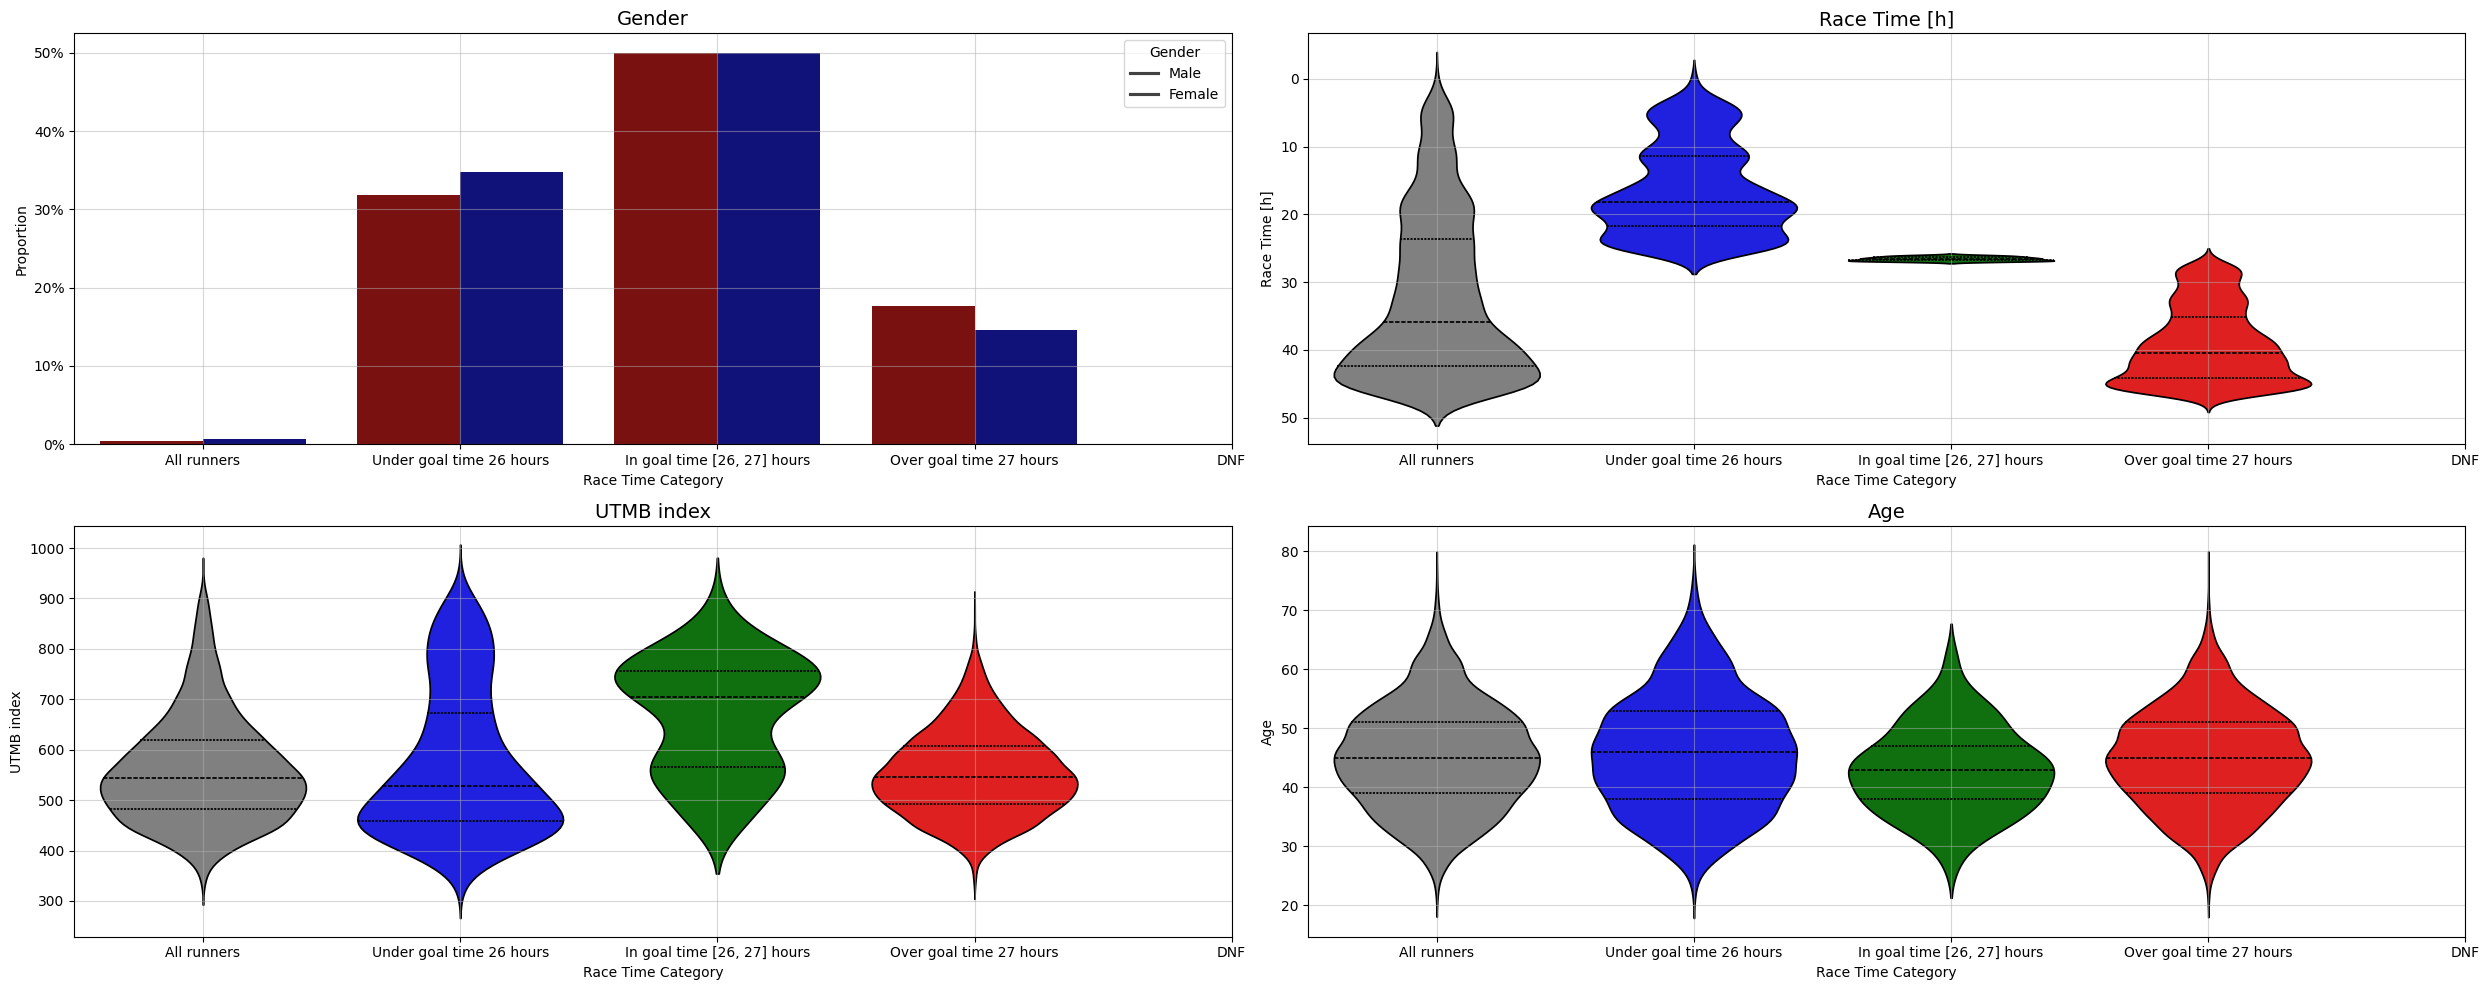

In [16]:
# Finish time goals aggregate values ~ Plot

keys_mapping = {
    "overall": "All runners",
    f"under_{goal_time}": f"Under goal time {goal_time-1} hours",
    f"in_{goal_time}": f"In goal time [{goal_time-1}, {goal_time}] hours",
    f"over_{goal_time}": f"Over goal time {goal_time} hours",
    "dnf": "DNF",
}

custom_palette = {
    "overall": "grey",    
    f"under_{goal_time}": "blue", 
    f"in_{goal_time}": "green",  
    f"over_{goal_time}": "red",
    "dnf": "black",
}

fig, ax = plt.subplots(2,2, figsize = (25, 10))

ax[0,0].set_title("Gender", fontsize=14)
prop_df = (
    utmb_split_results_full
    .groupby(["race_time_category", "runner_gender"])
    .size()
    .reset_index(name="count")
    .assign(proportion = lambda x: x.groupby("runner_gender")["count"].transform(lambda x: x / x.sum()))
)

sns.barplot(
    x="race_time_category", y="proportion", hue="runner_gender", data=prop_df,
    palette={"H": "darkblue", "F": "darkred"}, ax=ax[0,0]
)
ax[0,0].legend(title="Gender", labels=["Male", "Female"])
ax[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax[0,0].set_ylabel("Proportion")

stat_tmp = "runner_race_time_hours"
ax[0,1].set_title("Race Time [h]", fontsize=14)
sns.violinplot(
    x="race_time_category", y=stat_tmp, hue="race_time_category", data=utmb_split_results_full,
    split = False, legend=False, inner="quartile", palette=custom_palette, ax=ax[0,1]
)
ax[0,1].set_ylabel("Race Time [h]")
ax[0,1].invert_yaxis()

stat_tmp = "runner_overall_index"
ax[1,0].set_title("UTMB index", fontsize=14)
sns.violinplot(
    x="race_time_category", y=stat_tmp, hue="race_time_category", data=utmb_split_results_full,
    split = False, legend=False, inner="quartile", palette=custom_palette, ax=ax[1,0]
)
ax[1,0].set_ylabel("UTMB index")

stat_tmp = "runner_age"
ax[1,1].set_title("Age", fontsize=14)
sns.violinplot(
    x="race_time_category", y=stat_tmp, hue="race_time_category", data=utmb_split_results_full,
    split = False, legend=False, inner="quartile", palette=custom_palette, ax=ax[1,1]
)
ax[1,1].set_ylabel("Age")

for i in [0,1]:
    for j in [0,1]:
        ax[i,j].set_xlabel("Race Time Category")
        ax[i,j].set_xticks(range(len(keys_mapping)))
        ax[i,j].set_xticklabels([keys_mapping.get(cat, cat) for cat in keys_mapping.values()])
        ax[i,j].grid(alpha=.5)
    

plt.tight_layout()
plt.show()

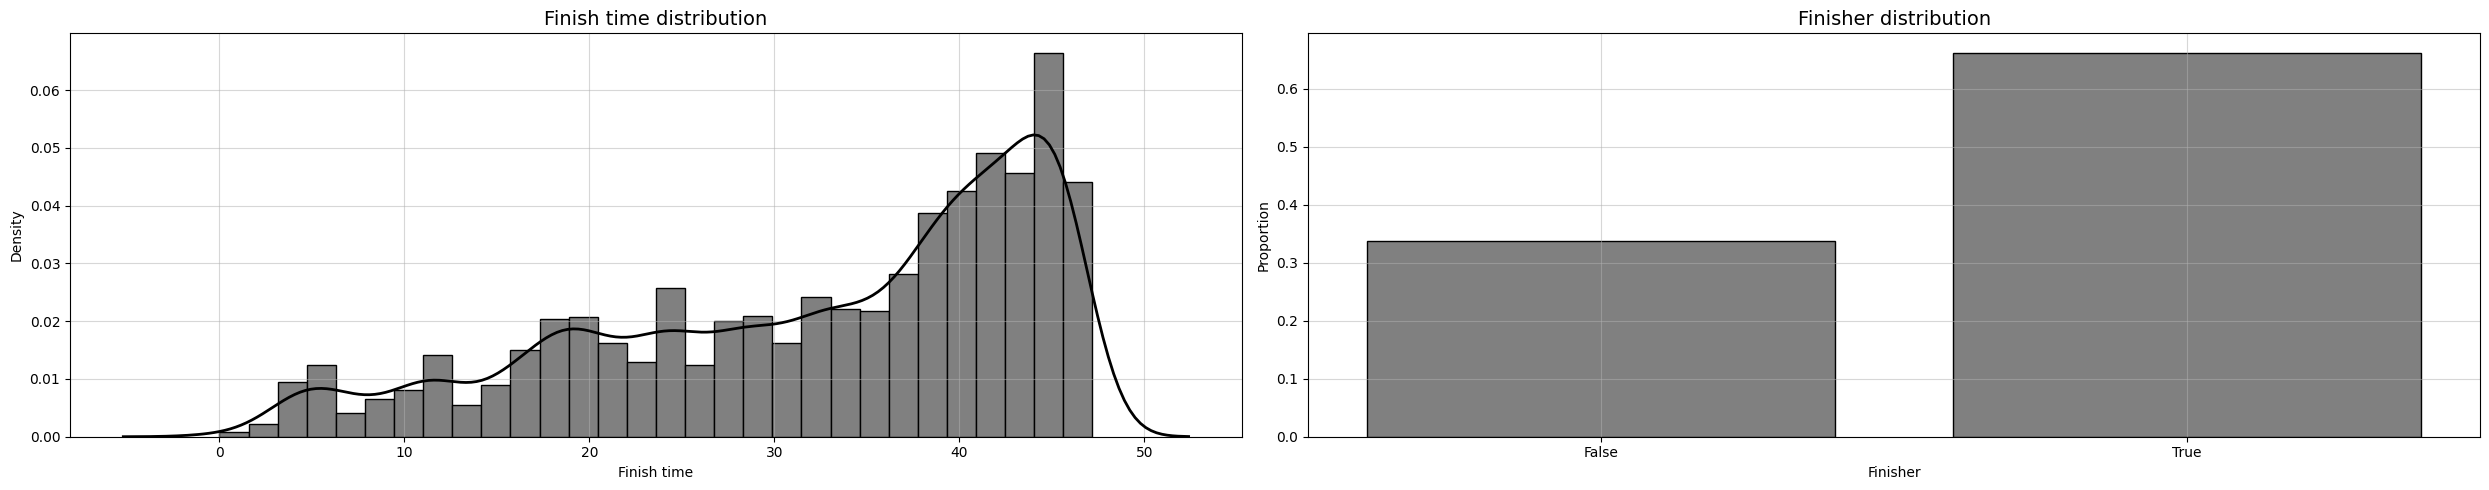

In [17]:
# Finishing time & Finish distribution

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Finish time distribution", fontsize=14)
ax[0].hist(utmb_split_results_full["runner_race_time_hours"], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(utmb_split_results_full["runner_race_time_hours"], ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

ax[1].set_title("Finisher distribution", fontsize=14)
prop_df =utmb_split_results_full["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[1].set_xlabel("Finisher")
ax[1].set_ylabel("Proportion")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

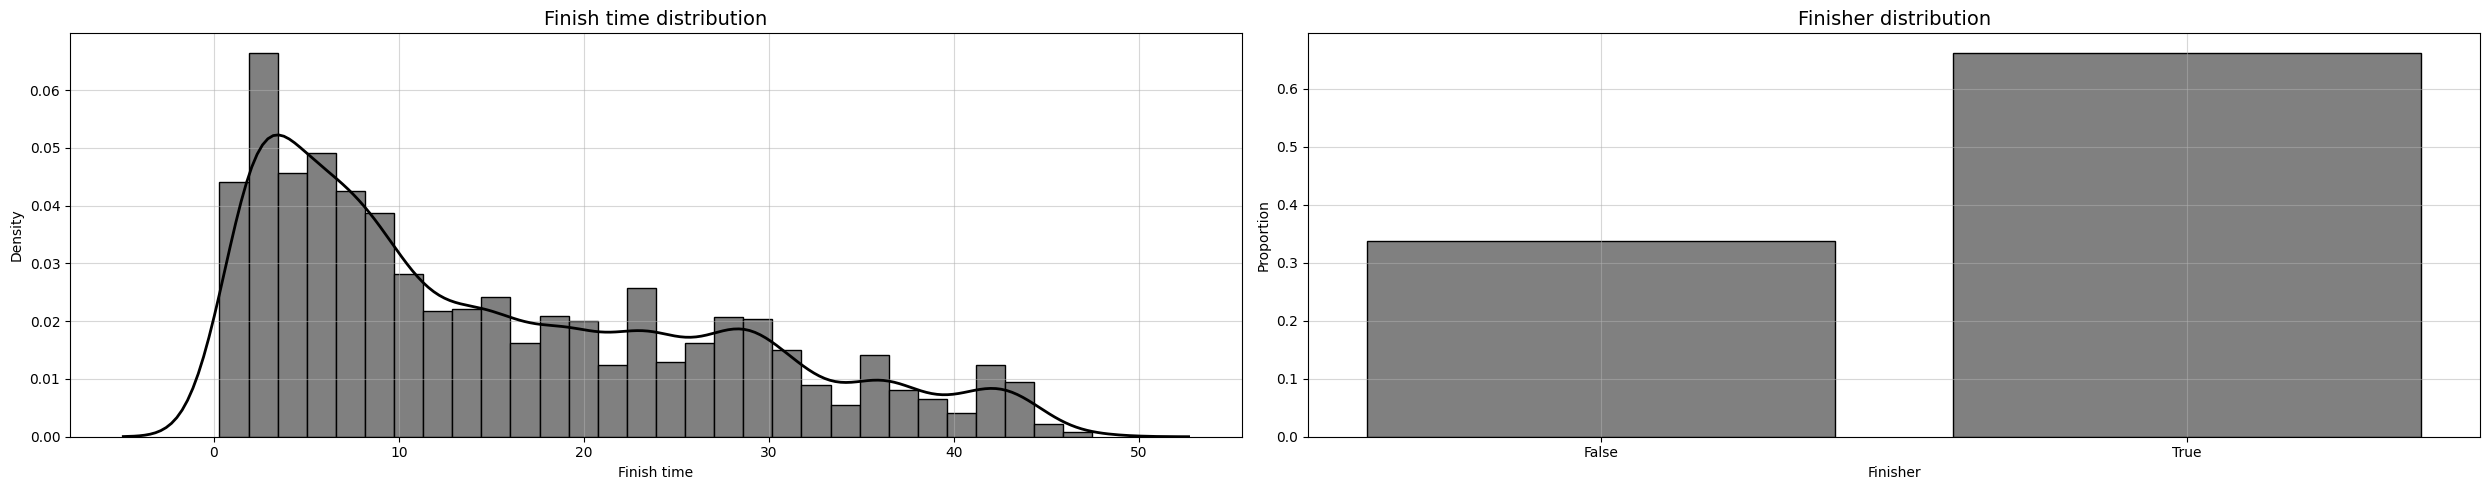

In [80]:
# Finishing time before cutoff & Finish distribution
cutoff_time = 47.5

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Finish time distribution", fontsize=14)
ax[0].hist(cutoff_time - utmb_split_results_full["runner_race_time_hours"], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(cutoff_time - utmb_split_results_full["runner_race_time_hours"], ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Finish time")

ax[1].set_title("Finisher distribution", fontsize=14)
prop_df =utmb_split_results_full["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[1].set_xlabel("Finisher")
ax[1].set_ylabel("Proportion")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

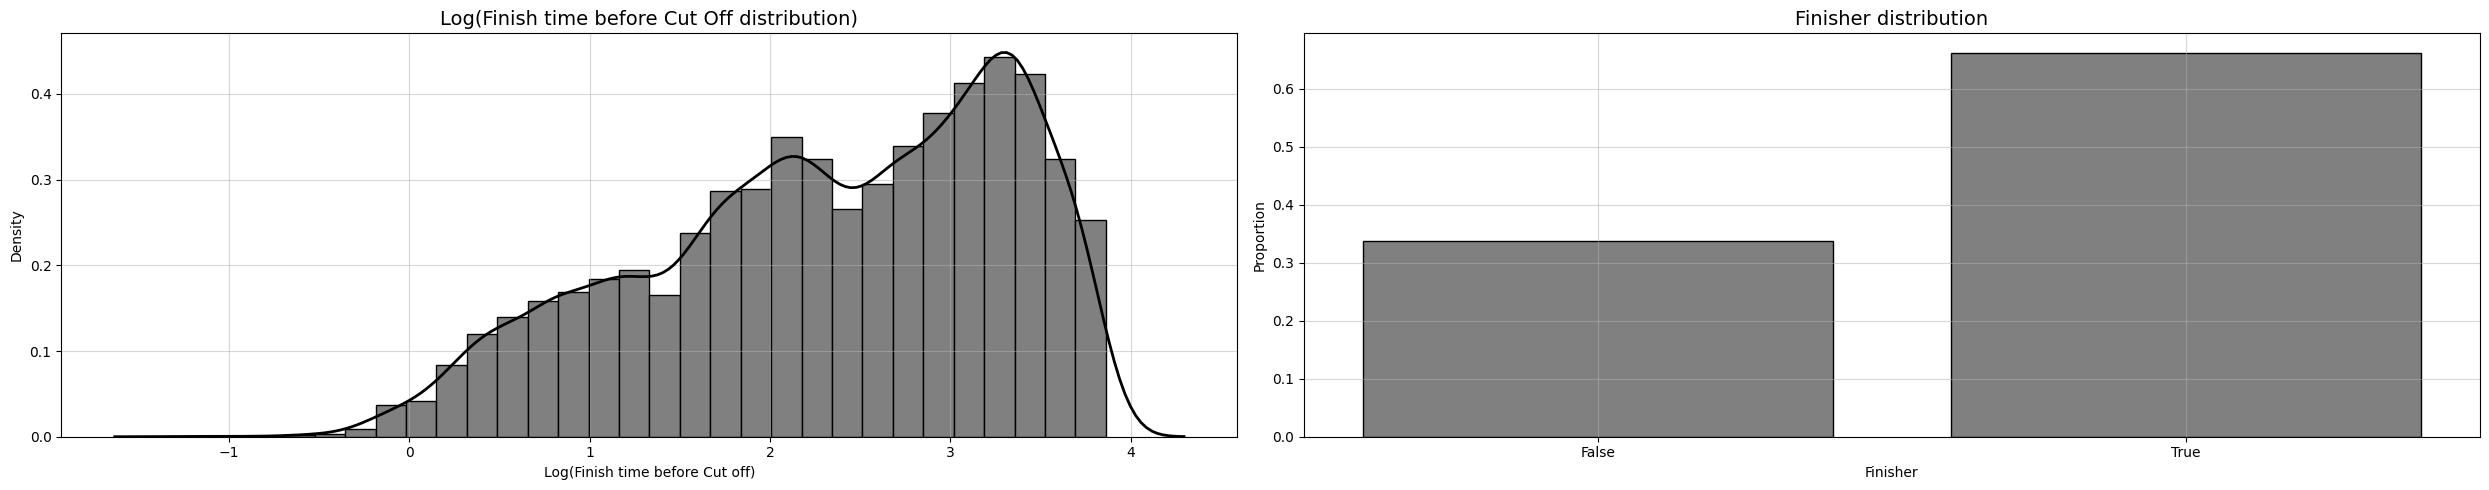

In [82]:
# Log(Finishing time before cutoff) & Finish distribution
cutoff_time = 47.5

fix, ax = plt.subplots(1,2, figsize=(25,5))

ax[0].set_title("Log(Finish time before Cut Off distribution)", fontsize=14)
ax[0].hist(np.log(cutoff_time - utmb_split_results_full["runner_race_time_hours"]), bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(np.log(cutoff_time - utmb_split_results_full["runner_race_time_hours"]), ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Log(Finish time before Cut off)")

ax[1].set_title("Finisher distribution", fontsize=14)
prop_df =utmb_split_results_full["runner_is_finisher"].value_counts(normalize=True) .reset_index()
sns.barplot(x="runner_is_finisher", y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[1])
ax[1].set_xlabel("Finisher")
ax[1].set_ylabel("Proportion")

for i in [0,1]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

In [ ]:
utmb_2025_results = get_race_results(
    race_id = "utmb", 
    race_year = 2025, 
    course_id = "utmb", 
    access_token = utmb_live_access_token, 
    printouts = False
    )

utmb_2025_runner_features = (
    utmb_2025_results[["race_start_time", "runner_url"]]
    .assign(runner_id = lambda x: x["runner_url"].str.split("runner/").str[1])
    # .apply(lambda x:)
    )

Retrieving data for: utmb ~ utmb ~ 2025


In [12]:
utmb_2025_runner_features

,race_start_time,runner_url,runner_id
0,2025-08-29T15:45:00.000Z,https://utmb.world/runner/1410311.tom.evans,1410311.tom.evans
1,2025-08-29T15:45:00.000Z,https://utmb.world/runner/1409387.ben.dhiman,1409387.ben.dhiman
2,2025-08-29T15:45:00.000Z,https://utmb.world/runner/1682129.josh.wade,1682129.josh.wade
3,2025-08-29T15:45:00.000Z,https://utmb.world/runner/1023247.ji.duo,1023247.ji.duo
4,2025-08-29T15:45:00.000Z,https://utmb.world/runner/154454.thibaut.garri...,154454.thibaut.garrivier
...,...,...,...
2484,2025-08-29T15:45:00.000Z,https://utmb.world/runner/3975905.li.he,3975905.li.he
2485,2025-08-29T15:45:00.000Z,https://utmb.world/runner/5496671.basile.darbe...,5496671.basile.darbellay
2486,2025-08-29T15:45:00.000Z,https://utmb.world/runner/4791393.jesus.alonso...,4791393.jesus.alonsoferreira
2487,2025-08-29T15:45:00.000Z,https://utmb.world/runner/917541.nicolas.marin,917541.nicolas.marin


In [ ]:
runner_id = "1410311.tom.evans"
race_date = pd.to_datetime(utmb_2025_runner_features["race_start_time"].iloc[0])
utmb_access_token

# def runner_features(runner_id, race_date, utmb_access_token):

runner_results = get_runner_results(
    runner_id=runner_id, 
    access_token=utmb_access_token
    )# .query("date.dt.date < @race_date.date()").copy()

runner_results["finished_rank_prop"] = (runner_results["total_finished"] - (runner_results["rank"]-1)) / runner_results["total_finished"]
runner_results["finished_rank_prop_gender"] = (runner_results["total_finished_gender"] - (runner_results["rank_gender"]-1)) / runner_results["total_finished_gender"]

runner_results_all = runner_results.loc[runner_results["date"].dt.date < race_date.date(), :].reset_index(drop=True).copy() 
runner_results_2years = runner_results_all.loc[runner_results_all["date"].dt.date >= race_date.date() - datetime.timedelta(days=2*365), :].reset_index(drop=True).copy()

In [ ]:
single_runner = utmb_2025_results.iloc[0]
runner_id = single_runner["runner_url"].split("runner/")[1]
race_date = pd.to_datetime(single_runner["race_start_time"])

runner_results = get_runner_results(
    runner_id= runner_id, 
    access_token = utmb_access_token
    )

def runner_stats_helper(data, race_date):

    # New helper stats
    runner_results["finished_rank_prop"] = (runner_results["total_finished"] - (runner_results["rank"]-1)) / runner_results["total_finished"]
    runner_results["finished_rank_prop_gender"] = (runner_results["total_finished_gender"] - (runner_results["rank_gender"]-1)) / runner_results["total_finished_gender"]

    # Finished races data
    data_finished = data.loc[data["race_utmb_index"].notnull(), :].reset_index(drop=True)

    # Pre calculate heavier ones
    if not data_finished.empty:

        avg_finisher_rank_prop_gender_trend = np.polyfit(
            pd.to_datetime(data_finished["date"]).map(pd.Timestamp.toordinal), 
            data_finished["finished_rank_prop_gender"], 
            1)[0] * 365

        avg_finisher_rank_prop_trend = np.polyfit(
            pd.to_datetime(data_finished["date"]).map(pd.Timestamp.toordinal), 
            data_finished["finished_rank_prop"], 
            1)[0] * 365
        
        utmb_index_trend = np.polyfit(
            pd.to_datetime(data_finished["date"]).map(pd.Timestamp.toordinal), 
            data_finished["race_utmb_index"], 
            1)[0] * 365
        
    else:
        avg_finisher_rank_prop_gender_trend = 0
        avg_finisher_rank_prop_trend = 0
        utmb_index_trend = 0

    # Calculate stats
    stats = {
    "nr_races": data.shape[0],
    "days_from_last_race": (race_date.date() - data["date"].dt.date.max()).days if not data.empty else np.nan,
    "finish_prop": 1-data["is_dnf"].mean(),
    "avg_distance": data["distance"].mean(),
    "avg_elevation_gain": data["elevation_gain"].mean(),
    "avg_elevation_gain_distance_race": (data["elevation_gain"] / data["distance"]).mean(),

    "avg_race_index": data["race_utmb_index"].mean(),
    "sd_race_index": data["race_utmb_index"].std(),
    "utmb_index_trend": utmb_index_trend,

    "avg_finisher_rank_prop": data["finished_rank_prop"].mean(),
    "sd_finisher_rank_prop": data["finished_rank_prop"].std(),
    "avg_finisher_rank_prop_trend": avg_finisher_rank_prop_trend,

    "avg_finisher_rank_prop_gender": data["finished_rank_prop_gender"].mean(),
    "sd_finisher_rank_prop_gender": data["finished_rank_prop_gender"].std(),
    "avg_finisher_rank_prop_gender_trend": avg_finisher_rank_prop_gender_trend,

    "avg_pace": ((data["race_time_hours"] * 60) / data["distance"]).mean(),
    "avg_elevation_gain_adjusted_pace": ((data["race_time_hours"] * 60) / (data["distance"] + (data["elevation_gain"] / 100))).mean(),
    "avg_vertical_speed": (data["elevation_gain"] / data["race_time_hours"]).mean(),

    }

    return stats


# All time
data = runner_results.copy()
prefix = "alltime"
stats_alltime = {}

data_all = data.loc[data["date"].dt.date < race_date.date()].reset_index(drop=True)
stats_all = runner_stats_helper(data = data_all)
stats_alltime = stats_alltime | {f"{prefix}_{key}_all": value for key, value in stats_all.items()}

data_100m = data_all.query("piCategory == '100m'").reset_index(drop=True)
stats_100m = runner_stats_helper(data = data_100m)
stats_alltime = stats_alltime | {f"{prefix}_{key}_100m": value for key, value in stats_100m.items()}

data_100k = data_all.query("piCategory == '100k'").reset_index(drop=True)
stats_100k = runner_stats_helper(data = data_100k)
stats_alltime = stats_alltime | {f"{prefix}_{key}_100k": value for key, value in stats_100k.items()}

data_sub100k = data_all.query("~piCategory.isin(['100m', '100k'])").reset_index(drop=True)
stats_sub100k = runner_stats_helper(data = data_sub100k)
stats_alltime = stats_alltime | {f"{prefix}_{key}_sub100k": value for key, value in stats_sub100k.items()}

# Last 2 years
data = runner_results.loc[runner_results["date"].dt.date >= race_date.date() - datetime.timedelta(days=2*365)].copy()
prefix = "last2y"
stats_last2y = {}

data_all = data.loc[data["date"].dt.date < race_date.date()].reset_index(drop=True)
stats_all = runner_stats_helper(data = data_all)
stats_last2y = stats_last2y | {f"{prefix}_{key}_all": value for key, value in stats_all.items()}

data_100m = data_all.query("piCategory == '100m'").reset_index(drop=True)
stats_100m = runner_stats_helper(data = data_100m)
stats_last2y = stats_last2y | {f"{prefix}_{key}_100m": value for key, value in stats_100m.items()}

data_100k = data_all.query("piCategory == '100k'").reset_index(drop=True)
stats_100k = runner_stats_helper(data = data_100k)
stats_last2y = stats_last2y | {f"{prefix}_{key}_100k": value for key, value in stats_100k.items()}

data_sub100k = data_all.query("~piCategory.isin(['100m', '100k'])").reset_index(drop=True)
stats_sub100k = runner_stats_helper(data = data_sub100k)
stats_last2y = stats_last2y | {f"{prefix}_{key}_sub100k": value for key, value in stats_sub100k.items()}

# Combine into a dataframe
df = pd.DataFrame([stats_alltime | stats_last2y])

---
Finish time univariate analysis

Notes: 
- Cut off time ~ 46h 30min
- UTMB has acceptance rate about 4.51%

In [23]:
# Help functions ~ Univariate analysis ~ Numeric

import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr

def univariate_LM_numeric(target, target_name, feature, feature_name, data, alpha=1.0):

    print("-----------------------------------------------------")
    print(f"{target_name} ~ {feature_name} ~> Univariate Linear Regression")
    print("-----------------------------------------------------\n")

    # Modeling ~> Linear regression
    data_clean = data[[target, feature]].dropna() 
    X = sm.add_constant(data_clean[[feature]])
    y = data_clean[target]

    model = sm.OLS(y, X)
    fit = model.fit()
    y_pred = fit.predict(X)

    # Metrics
    metrics = {
        "coef": fit.params[feature],
        "scaled coef": fit.params[feature] / np.std(data_clean[feature]),
        "p-value": fit.pvalues[feature],
        "standard error": fit.bse[feature],
        "scaled standard error": fit.bse[feature] / np.std(data_clean[feature]),
        "confidence interval": round(fit.conf_int().loc[feature], 4).tolist(),
        "scaled confidence interval": round(fit.conf_int().loc[feature] / np.std(data_clean[feature]), 4).tolist(),
        "R2": fit.rsquared,
        "R2 adjusted": fit.rsquared_adj,
        "MAE": mean_absolute_error(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
        "Pearson correlation coefficient": pearsonr(data_clean[feature], data_clean[target])[0]
    }

    metrics_df = pd.DataFrame([metrics])
    metrics_df.insert(0, "feature", feature)

    for key, value in metrics.items():
        if isinstance(value, list):
            print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
        else:
            print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

    # Plot
    fig, ax = plt.subplots(2, 2, figsize=(25, 10))

    # Feature distribution
    ax[0,0].set_title(f"{feature_name} Distribution", fontsize=14)
    ax[0,0].hist(data_clean[feature], bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
    sns.kdeplot(data_clean[feature], ax=ax[0,0], color="black", linewidth=2)
    ax[0,0].set_xlabel(feature_name)

    # Scatter plot with regression line
    ax[0,1].set_title(f"{target_name} ~ {feature_name} ~> Scatter plot & Regression line", fontsize=14)
    ax[0,1].scatter(data_clean[feature], data_clean[target], color="black", s=15, alpha=alpha)
    sns.regplot(x=data_clean[feature], y=data_clean[target], ax=ax[0,1], scatter=False, line_kws={"color":"red", "linewidth":2})
    ax[0,1].set_xlabel(feature_name)
    ax[0,1].set_ylabel(target_name)

    # Residuals scatter ~ Linearity assumption, Homoscedasticity, Outliers, Centering around zero
    ax[1,0].set_title("Predicted values vs. Residuals", fontsize=14)
    residuals = y - y_pred
    ax[1,0].scatter(y_pred, residuals, color="black", s=15, alpha=alpha)
    ax[1,0].axhline(0, color="red", linestyle="--")
    ax[1,0].set_xlabel(f"Predicted {target_name}")
    ax[1,0].set_ylabel("Residuals")
    ax[1,0].set_title(f"Residuals vs Predicted for {feature}")

    # Residuals KDE ~ Normality assumption
    ax[1,1].set_title("Residuals distribution", fontsize=14)
    ax[1,1].hist(residuals, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
    sns.kdeplot(residuals, ax=ax[1,1], color="black", linewidth=2)
    ax[1,1].set_title(f"Residuals Distribution for {feature_name}")
    ax[1,1].set_xlabel("Residuals")
    ax[1,1].set_ylabel("Density")

    for i in [0,1]:
        for j in [0,1]:
            ax[i,j].grid(alpha=.5)

    plt.tight_layout()
    plt.show()

    return metrics_df

In [24]:
# Help functions ~ Univariate analyis - Categorical
from pandas.api.types import is_numeric_dtype

target = "runner_race_time_hours"
target_name = "Race Time"
feature = "runner_gender"
feature_name = "Gender"
data = utmb_split_results_full

def univariate_LM_categorical(target, target_name, feature, feature_name, data, alpha=1.0):

    print("-----------------------------------------------------")
    print(f"{target_name} ~ {feature_name} ~> Univariate Linear Regression")
    print("-----------------------------------------------------\n")

    # Dummies
    dummies = pd.get_dummies(data[feature], prefix=feature, drop_first=True).astype(int)
    data = pd.concat([data, dummies], axis=1)
    dummies_names = list(dummies.columns)

    # Modeling ~> Linear regression
    data_clean = data[[target] + dummies_names].dropna() 
    X = sm.add_constant(data_clean[dummies_names])
    y = data_clean[target]

    model = sm.OLS(y, X)
    fit = model.fit()
    y_pred = fit.predict(X)

    # Metrics
    metrics_full = {}
    for dummy in dummies_names:
        metrics_dummy = {
            "coef": fit.params[dummy],
            "scaled coef": fit.params[dummy] / np.std(data_clean[dummy]),
            "p-value": fit.pvalues[dummy],
            "standard error": fit.bse[dummy],
            "scaled standard error": fit.bse[dummy] / np.std(data_clean[dummy]),
            "confidence interval": round(fit.conf_int().loc[dummy], 4).tolist(),
            "scaled confidence interval": round(fit.conf_int().loc[dummy] / np.std(data_clean[dummy]), 4).tolist(),
            "R2": fit.rsquared,
            "R2 adjusted": fit.rsquared_adj,
            "MAE": mean_absolute_error(y, y_pred),
            "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
            "Pearson correlation coefficient": pearsonr(data_clean[dummy], data_clean[target])[0],
        }

        metrics_full[dummy] = metrics_dummy

    for metric in metrics_full[dummies_names[0]]:
        values = [metrics_full[dummy][metric] for dummy in dummies_names]

        if isinstance(values[0], (list, tuple)):
            row_str = " ".join([
                f"[{dummy} = {[f'{v:.4f}' for v in val]}]" 
                for dummy, val in zip(dummies_names, values)
                ])
            
        else:  
            row_str = ", ".join([
                f"[{dummy} = {[f'{v:.4f}' for v in metrics_full[dummy][metric]]}]"
                if isinstance(metrics_full[dummy][metric], (list, tuple))
                else f"[{dummy} = {metrics_full[dummy][metric]:.4f}]"
                for dummy in dummies_names
            ])
        
        print(f"{metric} ~> {row_str}")

    model_metrics = {
        "R2": fit.rsquared,
        "R2 adjusted": fit.rsquared_adj,
        "MAE": mean_absolute_error(y, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y, y_pred))
    }

    for key, value in model_metrics.items():
        print(f"{key} ~> {value:.4f}")

    # Plot
    fig, ax = plt.subplots(2, 2, figsize=(25, 10))

    # Feature distribution
    ax[0,0].set_title(f"{feature_name} Distribution", fontsize=14)
    prop_df =data[feature].value_counts(normalize=True) .reset_index()
    sns.barplot(x=feature, y="proportion", data=prop_df, color="grey", edgecolor="black", ax=ax[0,0])
    ax[0,0].set_xlabel(feature_name)

    # Scatter plot with regression line
    ax[0,1].set_title(f"{target_name} ~ {feature_name} ~> Scatter plot & Regression line", fontsize=14)
    ax[0,1].scatter(data[feature], data[target], color="black", s=15, alpha=alpha)
    sns.regplot(x=data_clean[dummies_names], y=data_clean[target], ax=ax[0,1], scatter=False, line_kws={"color":"red", "linewidth":2})
    ax[0,1].set_xlabel(feature_name)
    ax[0,1].set_ylabel(target_name)

    # Residuals scatter ~ Linearity assumption, Homoscedasticity, Outliers, Centering around zero
    ax[1,0].set_title("Predicted values vs. Residuals", fontsize=14)
    residuals = y - y_pred
    ax[1,0].scatter(y_pred, residuals, color="black", s=15, alpha=alpha)
    ax[1,0].axhline(0, color="red", linestyle="--")
    ax[1,0].set_xlabel(f"Predicted {target_name}")
    ax[1,0].set_ylabel("Residuals")
    ax[1,0].set_title(f"Residuals vs Predicted for {feature_name}")

    # Residuals KDE ~ Normality assumption
    ax[1,1].set_title("Residuals distribution", fontsize=14)
    ax[1,1].hist(residuals, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
    sns.kdeplot(residuals, ax=ax[1,1], color="black", linewidth=2)
    ax[1,1].set_title(f"Residuals Distribution for {feature_name}")
    ax[1,1].set_xlabel("Residuals")
    ax[1,1].set_ylabel("Density")

    for i in [0,1]:
        for j in [0,1]:
            ax[i,j].grid(alpha=.5)

    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame(metrics_full).T.reset_index().rename(columns={"index": "feature"})
    return metrics_df

-----------------------------------------------------
Race Time ~ UTMB Index ~> Univariate Linear Regression
-----------------------------------------------------

coef ~> -0.0230
scaled coef ~> -0.0002
p-value ~> 0.0000
standard error ~> 0.0009
scaled standard error ~> 0.0000
confidence interval ~> ['-0.0247', '-0.0213']
scaled confidence interval ~> ['-0.0002', '-0.0002']
R2 ~> 0.0424
R2 adjusted ~> 0.0423
MAE ~> 9.7529
RMSE ~> 11.6992
Pearson correlation coefficient ~> -0.2058


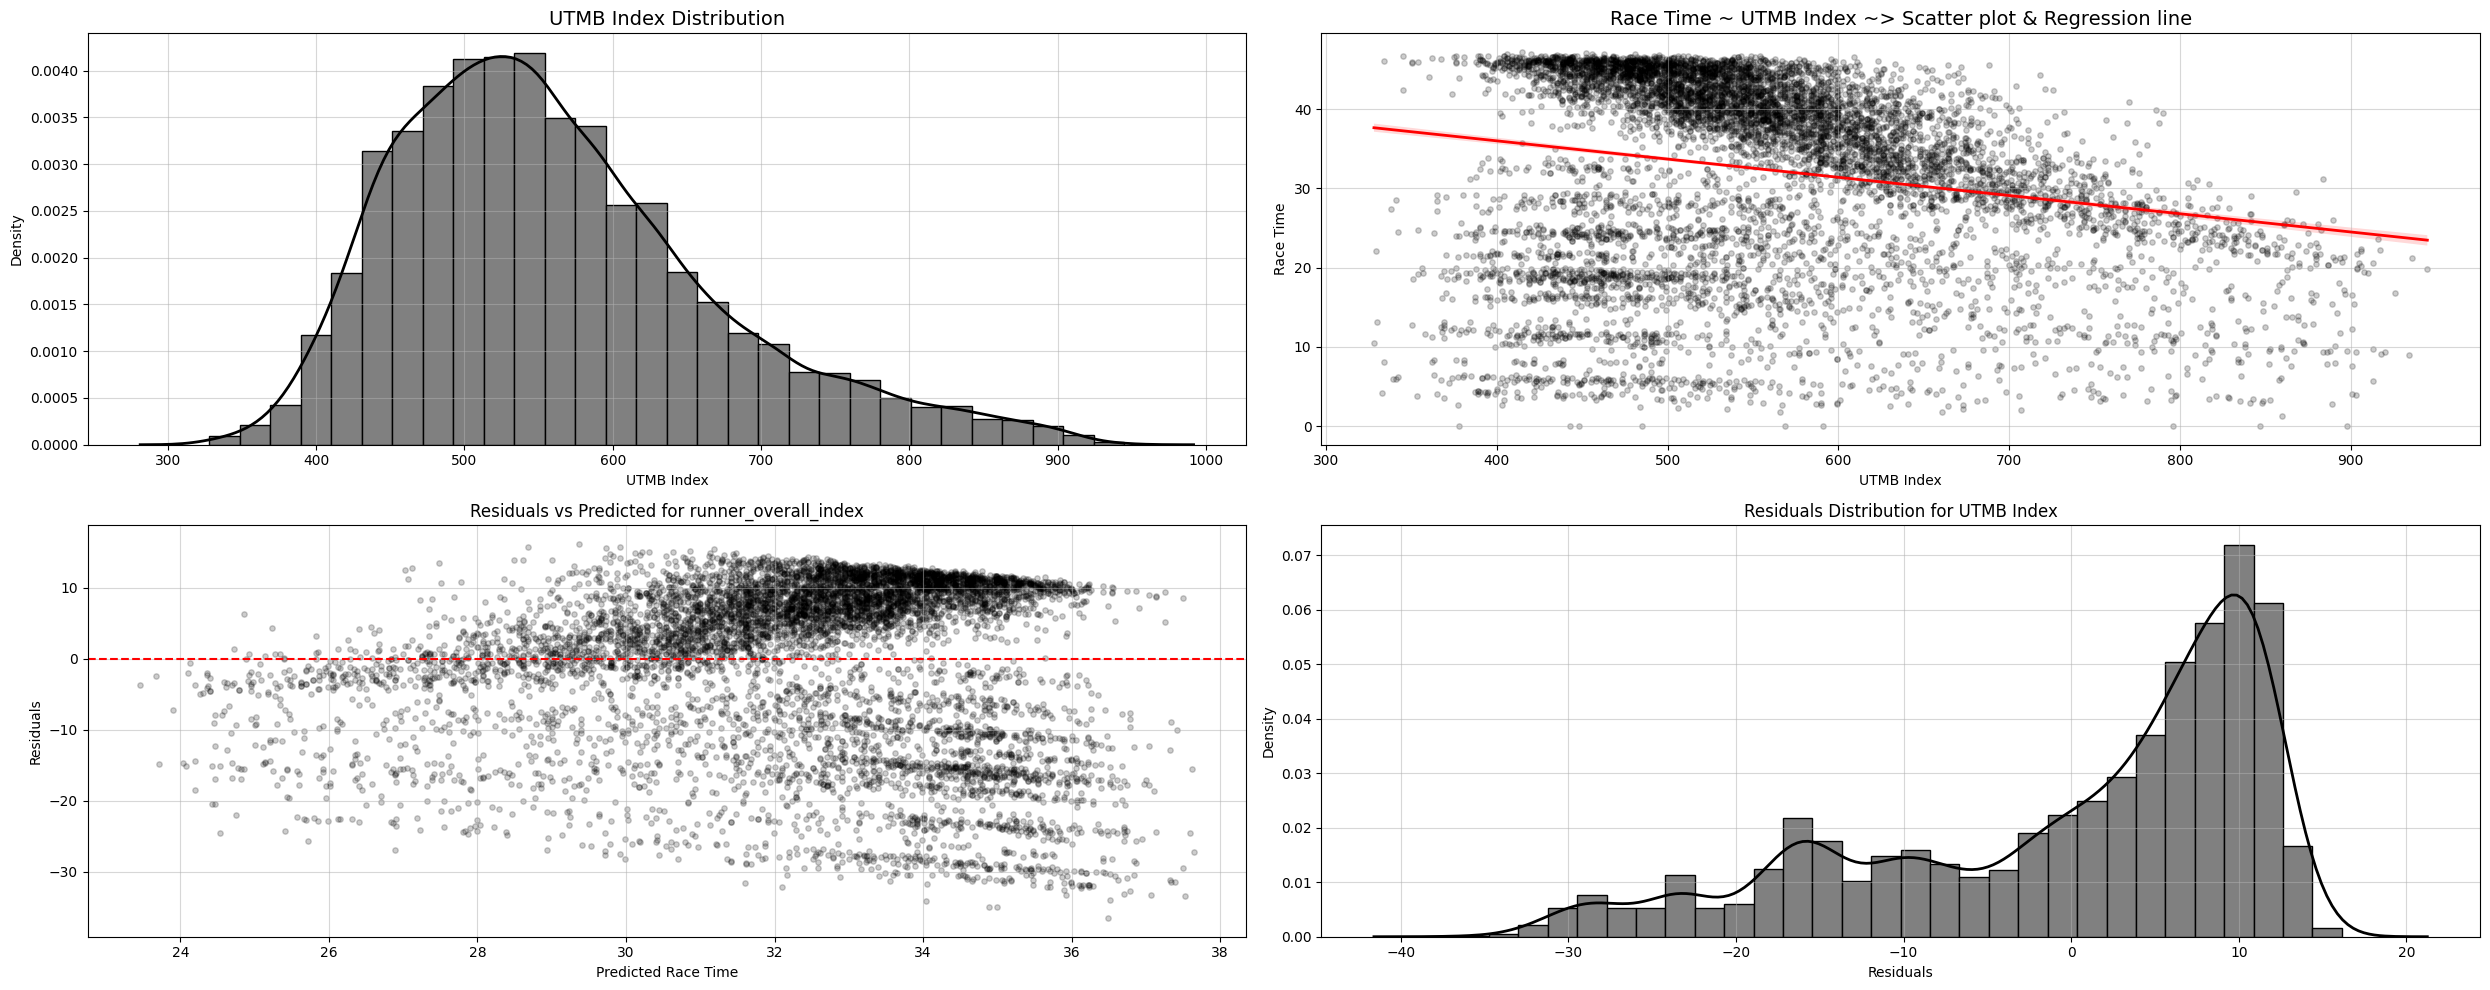

In [25]:
# UTMB index 

_ = univariate_LM_numeric(
    target = "runner_race_time_hours", 
    target_name = "Race Time", 
    feature = "runner_overall_index", 
    feature_name = "UTMB Index", 
    data = utmb_split_results_full,
    alpha=0.1
    )

-----------------------------------------------------
Gender ~ Gender ~> Univariate Linear Regression
-----------------------------------------------------

coef ~> [runner_gender_H = 1.1954]
scaled coef ~> [runner_gender_H = 3.6505]
p-value ~> [runner_gender_H = 0.0000]
standard error ~> [runner_gender_H = 0.2913]
scaled standard error ~> [runner_gender_H = 0.8897]
confidence interval ~> [runner_gender_H = ['0.6243', '1.7664']]
scaled confidence interval ~> [runner_gender_H = ['1.9066', '5.3944']]
R2 ~> [runner_gender_H = 0.0011]
R2 adjusted ~> [runner_gender_H = 0.0010]
MAE ~> [runner_gender_H = 10.1696]
RMSE ~> [runner_gender_H = 11.9723]
Pearson correlation coefficient ~> [runner_gender_H = 0.0327]
R2 ~> 0.0011
R2 adjusted ~> 0.0010
MAE ~> 10.1696
RMSE ~> 11.9723


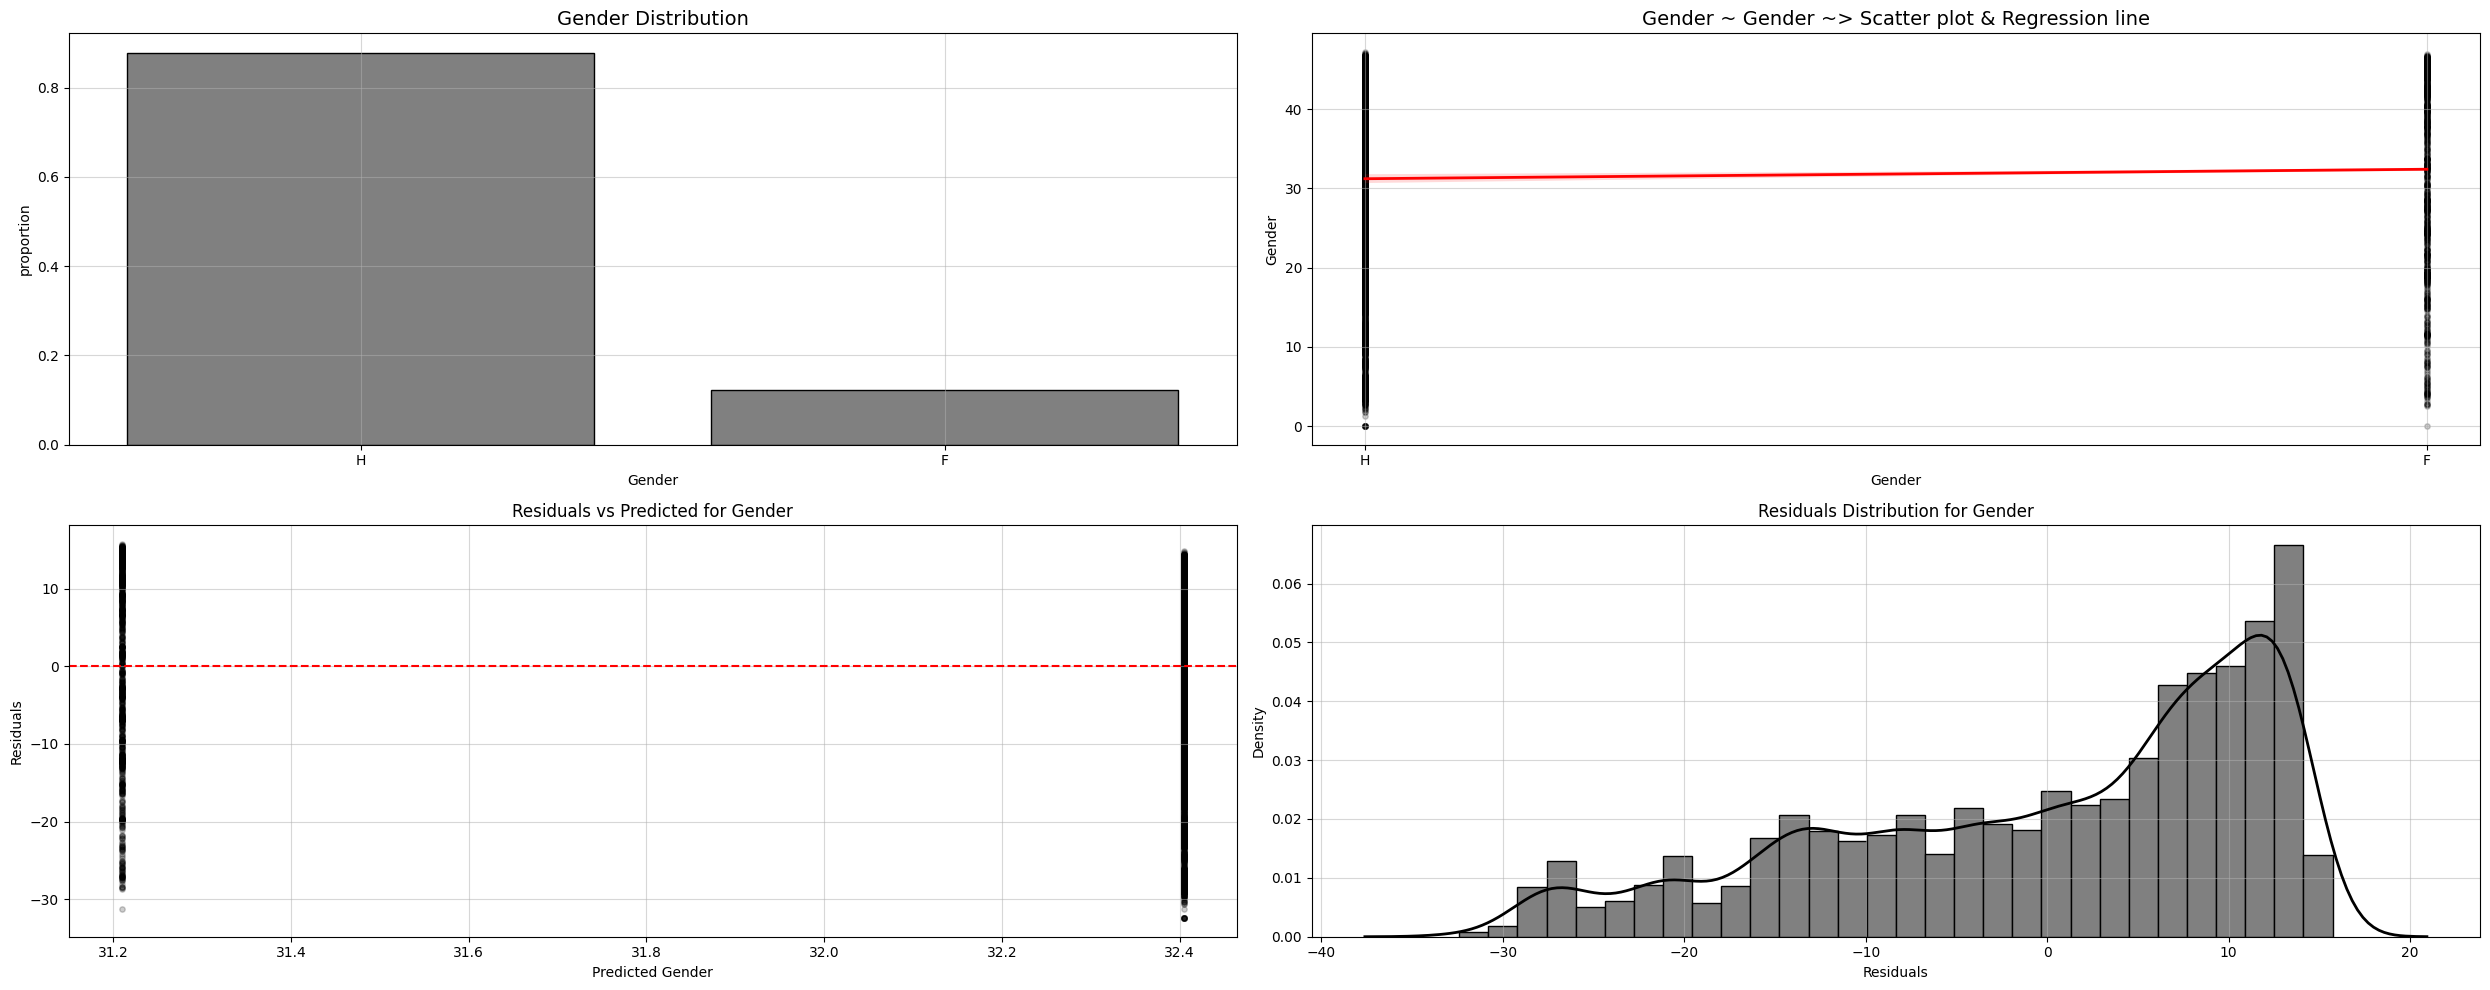

In [26]:
# Gender 
_ = univariate_LM_categorical(
    target = "runner_race_time_hours", 
    target_name = "Gender", 
    feature = "runner_gender", 
    feature_name = "Gender", 
    data = utmb_split_results_full,
    alpha=0.1
    )

-----------------------------------------------------
Race Time ~ Age ~> Univariate Linear Regression
-----------------------------------------------------

coef ~> 0.0043
scaled coef ~> 0.0005
p-value ~> 0.6924
standard error ~> 0.0108
scaled standard error ~> 0.0012
confidence interval ~> ['-0.0169', '0.0255']
scaled confidence interval ~> ['-0.0019', '0.0029']
R2 ~> 0.0000
R2 adjusted ~> -0.0001
MAE ~> 10.1829
RMSE ~> 11.9786
Pearson correlation coefficient ~> 0.0032


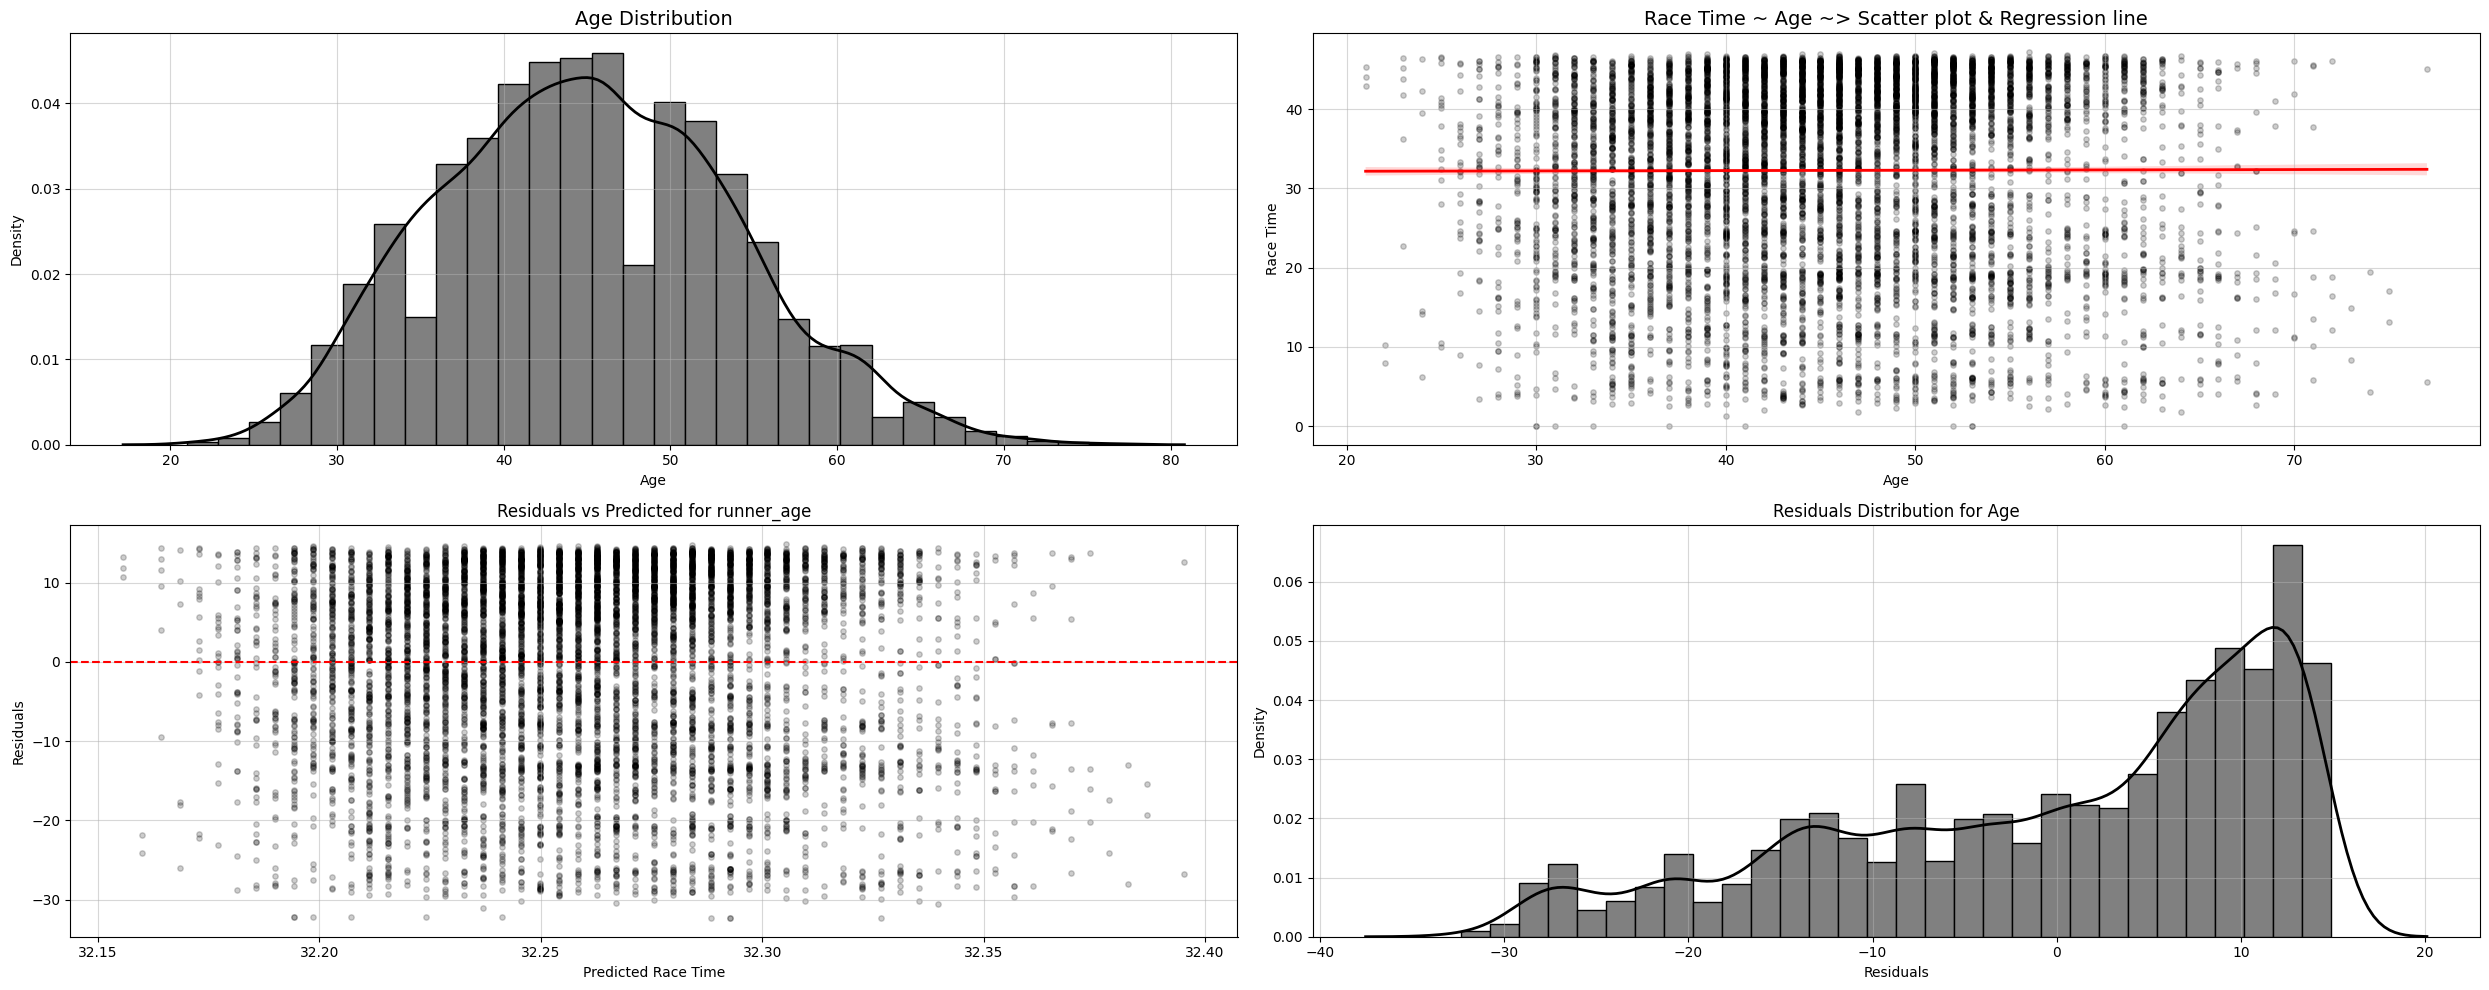

In [27]:
# Age

_ = univariate_LM_numeric(
    target = "runner_race_time_hours", 
    target_name = "Race Time", 
    feature = "runner_age", 
    feature_name = "Age", 
    data = utmb_split_results_full,
    alpha=0.1
    )

---
Finish boolean univariate anaylsis

In [28]:
# Help functions ~ Univariate analysis ~ Numeric

import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve

def univariate_Logit_numeric(target, target_name, feature, feature_name, data):

    print("-----------------------------------------------------")
    print(f"{target_name} ~ {feature_name} ~> Univariate Logistic Regression")
    print("-----------------------------------------------------\n")

    # Modeling ~> Logistic regression
    data_clean = data[[target, feature]].dropna() 
    X = sm.add_constant(data_clean[[feature]])
    y = data_clean[target]

    model = sm.Logit(y, X)
    fit = model.fit()
    y_pred = fit.predict(X)

    # Metrics
    metrics = {
        "coef": fit.params[feature],
        "scaled coef": fit.params[feature] / np.std(data_clean[feature]),
        "p-value": fit.pvalues[feature],
        "standard error": fit.bse[feature],
        "scaled standard error": fit.bse[feature] / np.std(data_clean[feature]),
        "confidence interval": round(fit.conf_int().loc[feature], 4).tolist(),
        "scaled confidence interval": round(fit.conf_int().loc[feature] / np.std(data_clean[feature]), 4).tolist(),
        "Pseudo R2": fit.prsquared,
        "Log-Likelihood": fit.llf,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "ROC-AUC": roc_auc_score(y, y_pred)
    }

    
    metrics_df = pd.DataFrame([metrics])
    metrics_df.insert(0, "feature", feature)

    for key, value in metrics.items():
        if isinstance(value, list):
            print(f"{key} ~> {[f'{v:.4f}' for v in value]}")
        else:
            print(f"{key} ~> {value:.4f}" if isinstance(value, float) else f"{key} ~> {value}")

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(25, 5))

    # Predicted proability distribution
    ax[0].set_title("Predicted Probability Distribution")
    ax[0].hist(y_pred, bins=30, color="grey", edgecolor="black", density=True)
    sns.kdeplot(y_pred, ax=ax[0], color="black", linewidth=2)
    ax[0].set_xlabel("Predicted probability")
    ax[0].set_ylabel("Density")

    # Predicted probabilities distribution in comparison to actual values
    ax[1].set_title(f"{target_name} ~ {feature_name} ~> Distribution", fontsize=14, alpha=.8)
    sns.violinplot(
        x=y, y=y_pred, hue=y,
        split = False, legend=False, inner="quartile", palette={0: "#3898FF", 1: "#FF4040"}, ax=ax[1]
    )
    ax[1].set_xlabel("Actual Boolean")
    ax[1].set_ylabel("Predicted probability")

    # ROC and AUC
    ax[2].set_title("ROC Curve", fontsize=14)
    fpr, tpr, thresholds = roc_curve(y, y_pred)
    auc_score = roc_auc_score(y, y_pred)
    ax[2].plot(fpr, tpr, color="black", label=f"ROC curve, AUC = {auc_score:.3f}")
    ax[2].plot([0, 1], [0, 1], color="blue", linestyle="--", label="Random classifier")
    ax[2].set_xlabel("False Positive Rate")
    ax[2].set_ylabel("True Positive Rate")
    ax[2].legend(fontsize=14)

    for i in [0,1,2]:
        ax[i].grid(alpha=.5)

    plt.tight_layout()
    plt.show()

    return metrics_df

In [29]:
# Help functions ~ Univariate analysis ~ Categorical

import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve

def univariate_Logit_categorical(target, target_name, feature, feature_name, data):

    print("-----------------------------------------------------")
    print(f"{target_name} ~ {feature_name} ~> Univariate Logistic Regression")
    print("-----------------------------------------------------\n")

    # Dummies
    dummies = pd.get_dummies(data[feature], prefix=feature, drop_first=True).astype(int)
    data = pd.concat([data, dummies], axis=1)
    dummies_names = list(dummies.columns)

    # Modeling ~> Logistic regression
    data_clean = data[[target] + dummies_names].dropna() 
    X = sm.add_constant(data_clean[dummies_names])
    y = data_clean[target]

    model = sm.Logit(y, X)
    fit = model.fit()
    y_pred = fit.predict(X)

    # Metrics
    metrics_full = {}
    for dummy in dummies_names:
        metrics_dummy = {
            "coef": fit.params[dummy],
            "scaled coef": fit.params[dummy] / np.std(data_clean[dummy]),
            "p-value": fit.pvalues[dummy],
            "standard error": fit.bse[dummy],
            "scaled standard error": fit.bse[dummy] / np.std(data_clean[dummy]),
            "confidence interval": round(fit.conf_int().loc[dummy], 4).tolist(),
            "scaled confidence interval": round(fit.conf_int().loc[dummy] / np.std(data_clean[dummy]), 4).tolist(),
            "Pseudo R2": fit.prsquared,
            "Log-Likelihood": fit.llf,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "ROC-AUC": roc_auc_score(y, y_pred)
        }
        
        metrics_full[dummy] = metrics_dummy
    
    for metric in metrics_full[dummies_names[0]]:
        values = [metrics_full[dummy][metric] for dummy in dummies_names]

        if isinstance(values[0], (list, tuple)):
            row_str = " ".join([
                f"[{dummy} = {[f'{v:.4f}' for v in val]}]" 
                for dummy, val in zip(dummies_names, values)
                ])
            
        else:  
            row_str = ", ".join([
                f"[{dummy} = {[f'{v:.4f}' for v in metrics_full[dummy][metric]]}]"
                if isinstance(metrics_full[dummy][metric], (list, tuple))
                else f"[{dummy} = {metrics_full[dummy][metric]:.4f}]"
                for dummy in dummies_names
            ])

        print(f"{metric} ~> {row_str}")

    # Plot
    fig, ax = plt.subplots(1, 3, figsize=(25, 5))

    # Predicted proability distribution
    ax[0].set_title("Predicted Probability Distribution")
    ax[0].hist(y_pred, bins=30, color="grey", edgecolor="black", density=True)
    sns.kdeplot(y_pred, ax=ax[0], color="black", linewidth=2)
    ax[0].set_xlabel("Predicted probability")
    ax[0].set_ylabel("Density")

    # Predicted probabilities distribution in comparison to actual values
    ax[1].set_title(f"{target_name} ~ {feature_name} ~> Distribution", fontsize=14, alpha=.8)
    sns.violinplot(
        x=y, y=y_pred, hue=y,
        split = False, legend=False, inner="quartile", palette={0: "#3898FF", 1: "#FF4040"}, ax=ax[1]
    )
    ax[1].set_xlabel("Actual Boolean")
    ax[1].set_ylabel("Predicted probability")

    # ROC and AUC
    ax[2].set_title("ROC Curve", fontsize=14)
    fpr, tpr, thresholds = roc_curve(y, y_pred)
    auc_score = roc_auc_score(y, y_pred)
    ax[2].plot(fpr, tpr, color="black", label=f"ROC curve, AUC = {auc_score:.3f}")
    ax[2].plot([0, 1], [0, 1], color="blue", linestyle="--", label="Random classifier")
    ax[2].set_xlabel("False Positive Rate")
    ax[2].set_ylabel("True Positive Rate")
    ax[2].legend(fontsize=14)

    for i in [0,1,2]:
        ax[i].grid(alpha=.5)

    plt.tight_layout()
    plt.show()

    metrics_df = pd.DataFrame(metrics_full).T.reset_index().rename(columns={"index": "feature"})
    return metrics_df

-----------------------------------------------------
Finisher ~ UTMB Index ~> Univariate Logistic Regression
-----------------------------------------------------

Optimization terminated successfully.
         Current function value: 0.629348
         Iterations 5
coef ~> 0.0026
scaled coef ~> 0.0000
p-value ~> 0.0000
standard error ~> 0.0002
scaled standard error ~> 0.0000
confidence interval ~> ['0.0023', '0.0029']
scaled confidence interval ~> ['0.0000', '0.0000']
Pseudo R2 ~> 0.0125
Log-Likelihood ~> -9685.6643
AIC ~> 19375.3286
BIC ~> 19390.6116
ROC-AUC ~> 0.6120


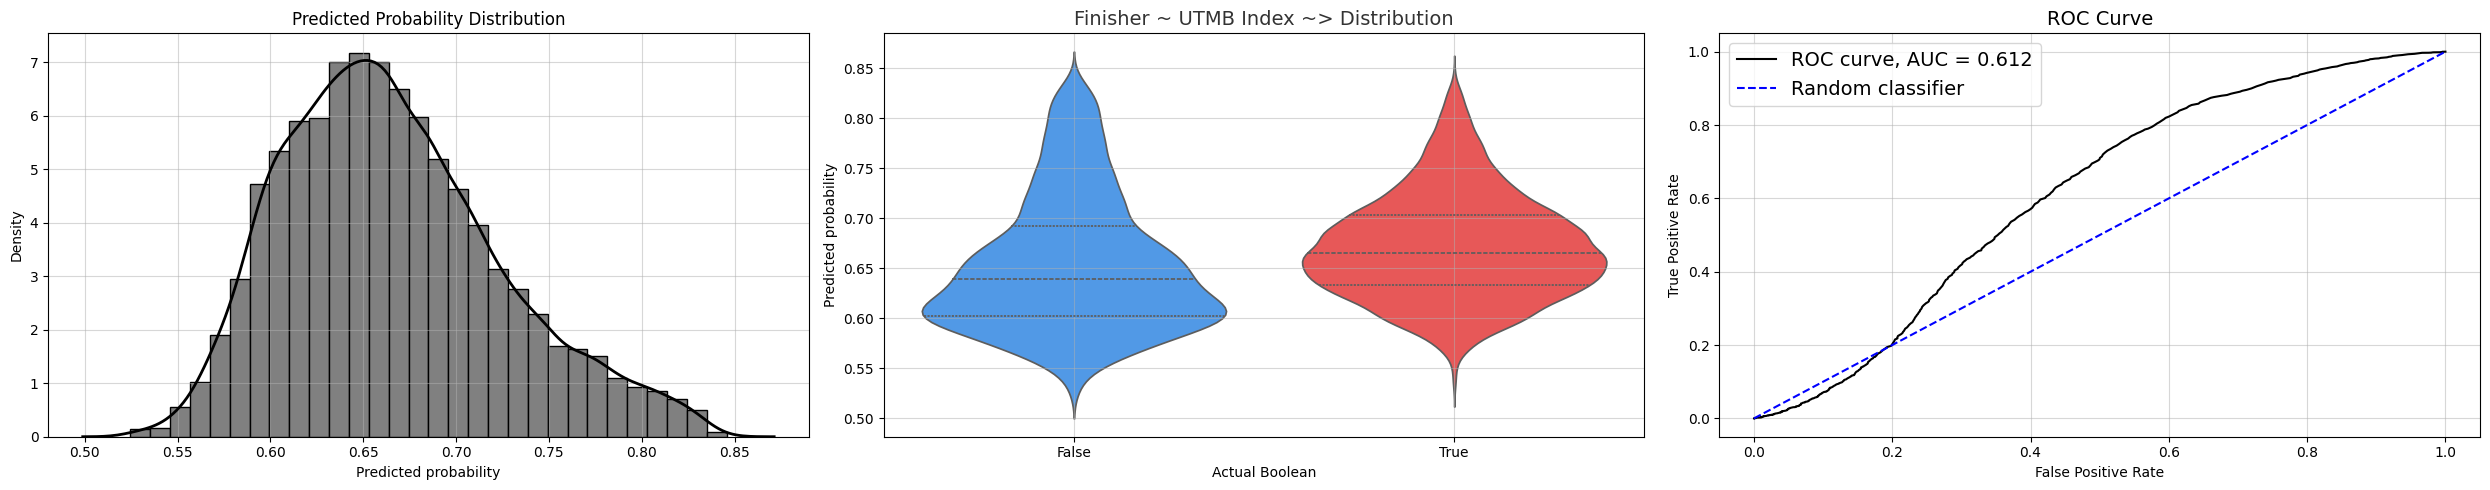

In [30]:
# UTMB index 

_ = univariate_Logit_numeric(
    target = "runner_is_finisher", 
    target_name = "Finisher", 
    feature = "runner_overall_index", 
    feature_name = "UTMB Index", 
    data = utmb_split_results_full,
    )

-----------------------------------------------------
Finisher ~ Gender ~> Univariate Logistic Regression
-----------------------------------------------------

Optimization terminated successfully.
         Current function value: 0.637956
         Iterations 4
coef ~> [runner_gender_H = 0.3711]
scaled coef ~> [runner_gender_H = 1.1334]
p-value ~> [runner_gender_H = 0.0000]
standard error ~> [runner_gender_H = 0.0497]
scaled standard error ~> [runner_gender_H = 0.1518]
confidence interval ~> [runner_gender_H = ['0.2737', '0.4686']]
scaled confidence interval ~> [runner_gender_H = ['0.8359', '1.4309']]
Pseudo R2 ~> [runner_gender_H = 0.0027]
Log-Likelihood ~> [runner_gender_H = -10049.0892]
AIC ~> [runner_gender_H = 20102.1784]
BIC ~> [runner_gender_H = 20117.5078]
ROC-AUC ~> [runner_gender_H = 0.5207]


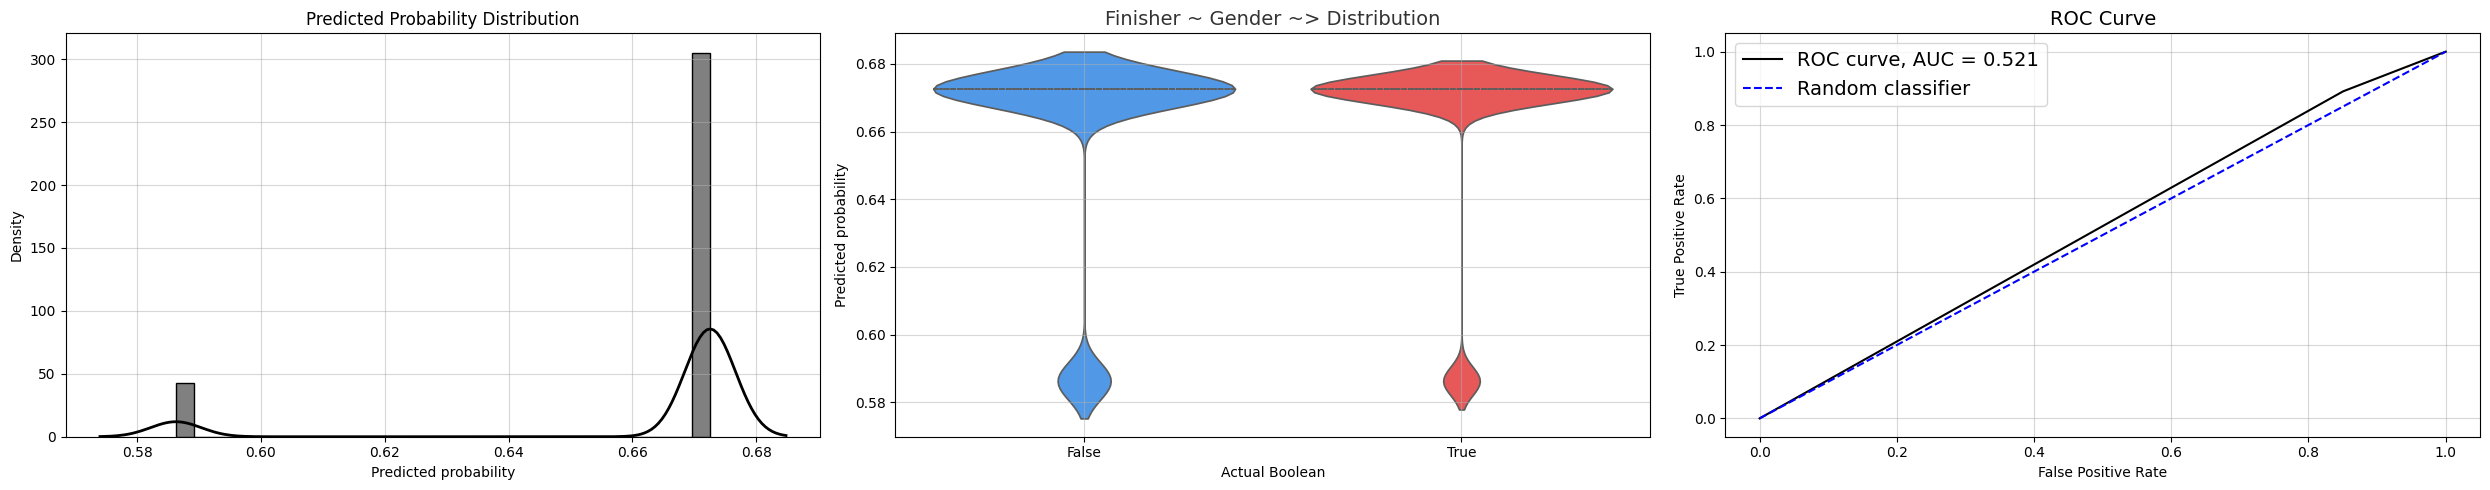

In [31]:
# Gender 

_ = univariate_Logit_categorical(
    target = "runner_is_finisher", 
    target_name = "Finisher", 
    feature = "runner_gender", 
    feature_name = "Gender", 
    data = utmb_split_results_full,
    )

-----------------------------------------------------
Finisher ~ Age ~> Univariate Logistic Regression
-----------------------------------------------------

Optimization terminated successfully.
         Current function value: 0.628702
         Iterations 5
coef ~> -0.0358
scaled coef ~> -0.0041
p-value ~> 0.0000
standard error ~> 0.0020
scaled standard error ~> 0.0002
confidence interval ~> ['-0.0397', '-0.0320']
scaled confidence interval ~> ['-0.0045', '-0.0036']
Pseudo R2 ~> 0.0172
Log-Likelihood ~> -9903.3112
AIC ~> 19810.6224
BIC ~> 19825.9518
ROC-AUC ~> 0.5816


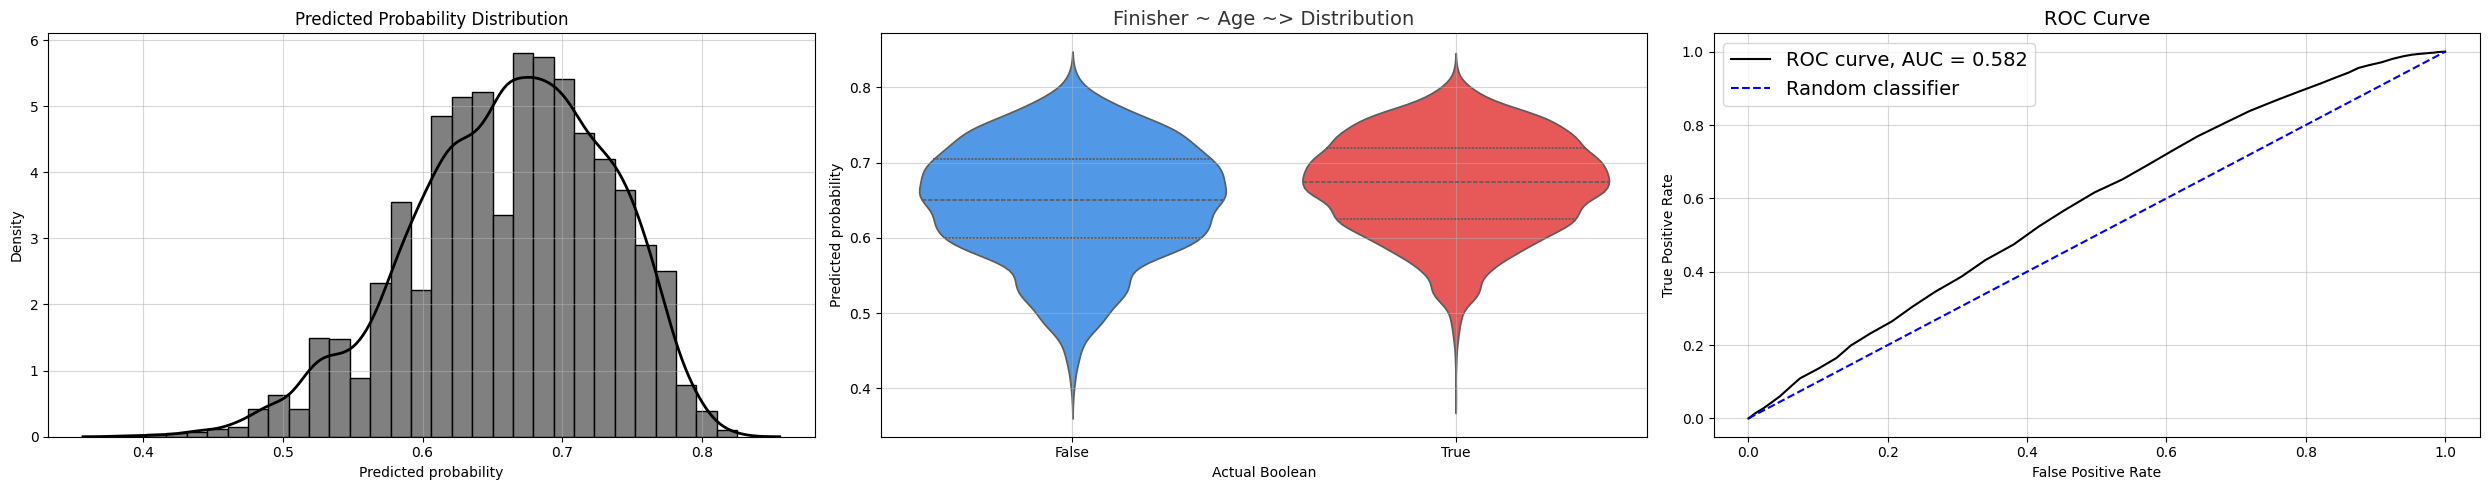

In [32]:
# Age

_ = univariate_Logit_numeric(
    target = "runner_is_finisher", 
    target_name = "Finisher", 
    feature = "runner_age", 
    feature_name = "Age", 
    data = utmb_split_results_full,
    )

---
Full models

Optimization terminated successfully.
         Current function value: 0.622108
         Iterations 5


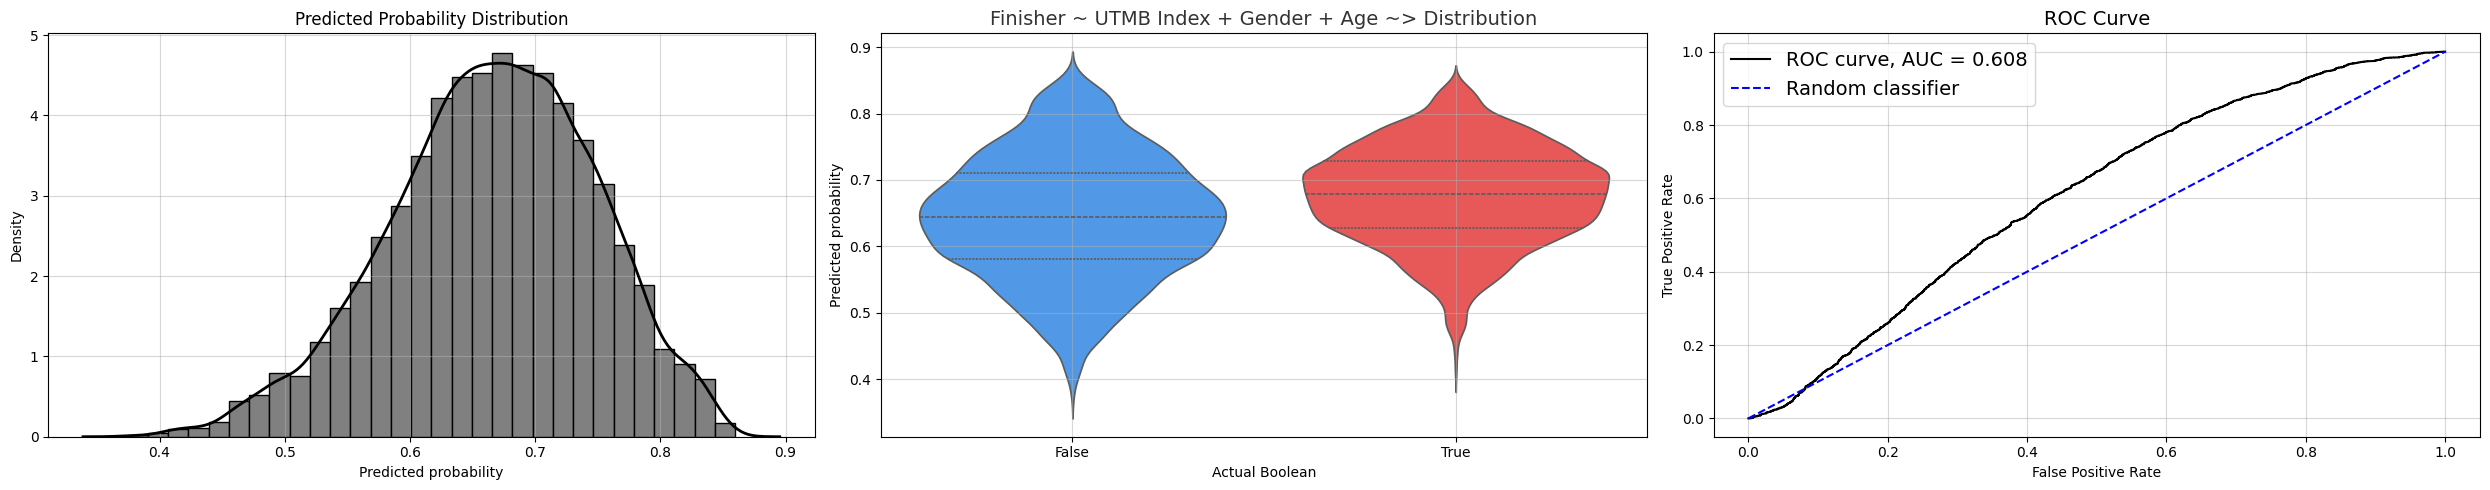

,feature,coef,scaled_coef,p_value,std_err,scaled_std_err,conf_int,scaled_conf_int
0,const,0.749450,inf,8.203867e-06,0.168046,inf,"[0.4201, 1.0788]","[nan, nan]"
1,runner_overall_index,0.001618,0.000015,1.823400e-18,0.000185,0.000002,"[0.0013, 0.002]","[nan, nan]"
2,gender_Male,0.384238,1.172290,6.406869e-14,0.051235,0.156316,"[0.2838, 0.4847]","[nan, nan]"
3,runner_age,-0.028501,-0.003230,1.757226e-40,0.002140,0.000243,"[-0.0327, -0.0243]","[nan, nan]"


Pseudo R2 = 0.02387211150592239
Log-Likelihood = -9574.235561469415
AIC = 19156.47112293883
BIC = 19187.037015846163
ROC-AUC= 0.6079975699190696


In [33]:
# Simple logistic model ~ Finish/DNF
from sklearn.metrics import roc_auc_score, roc_curve

target = "runner_is_finisher"
target_name = "Finisher"
features = ["runner_overall_index", "runner_gender", "runner_age"]
feature_names = ["UTMB Index", "Gender", "Age"]
data = utmb_split_results_full.copy()
alpha = .3

# Dummies for Gender
data["gender_Male"] = data["runner_gender"].map({"H": 1, "F": 0})

# Prepare
data_model = data[[target] + ["gender_Male" if x=="runner_gender" else x for x in features]].dropna() 
X = sm.add_constant(data_model.drop(columns=target))
y = data_model[target]

logit_model = sm.Logit(y, X)
logit_fit = logit_model.fit()
y_pred = logit_fit.predict(X)
y_pred_summary = logit_fit.get_prediction(X)

# Metrics 
metrics = {
    "coefs": logit_fit.params.reset_index().rename(columns={"index": "feature", 0: "coef"}),
    "scaled coefs": (logit_fit.params / np.std(X, axis=0)).reset_index().rename(columns={"index": "feature", 0: "scaled_coef"}),
    "p-values": logit_fit.pvalues.reset_index().rename(columns={"index": "feature", 0: "p_value"}),
    "standard errors": logit_fit.bse.reset_index().rename(columns={"index": "feature", 0: "std_err"}),
    "scaled standard errors": (logit_fit.bse / np.std(X, axis=0)).reset_index().rename(columns={"index": "feature", 0: "scaled_std_err"}),
    "confidence intervals": round(logit_fit.conf_int(), 4).apply(lambda x: "[" + str(x[0]) + ", " + str(x[1]) + "]", axis=1).reset_index().rename(columns={"index": "feature", 0: "conf_int"}),
    "scaled confidence intervals": round(logit_fit.conf_int() / np.std(X, axis=0), 4).apply(lambda x: "[" + str(x[0]) + ", " + str(x[1]) + "]", axis=1).reset_index().rename(columns={"index": "feature", 0: "scaled_conf_int"}),
    "Pseudo R2": logit_fit.prsquared,
    "Log-Likelihood": logit_fit.llf,
    "AIC": logit_fit.aic,
    "BIC": logit_fit.bic,
    "ROC-AUC": roc_auc_score(y, y_pred)
}

# Plot
fig, ax = plt.subplots(1, 3, figsize=(25, 5))

# Predicted proability distribution
ax[0].set_title("Predicted Probability Distribution")
ax[0].hist(y_pred, bins=30, color="grey", edgecolor="black", density=True)
sns.kdeplot(y_pred, ax=ax[0], color="black", linewidth=2)
ax[0].set_xlabel("Predicted probability")
ax[0].set_ylabel("Density")

# Predicted probabilities distribution in comparison to actual values
ax[1].set_title(f"{target_name} ~ {" + ".join(feature_names)} ~> Distribution", fontsize=14, alpha=.8)
sns.violinplot(
    x=y, y=y_pred, hue=y,
    split = False, legend=False, inner="quartile", palette={0: "#3898FF", 1: "#FF4040"}, ax=ax[1]
)
ax[1].set_xlabel("Actual Boolean")
ax[1].set_ylabel("Predicted probability")

# ROC and AUC
ax[2].set_title("ROC Curve", fontsize=14)
fpr, tpr, thresholds = roc_curve(y, y_pred)
auc_score = roc_auc_score(y, y_pred)
ax[2].plot(fpr, tpr, color="black", label=f"ROC curve, AUC = {auc_score:.3f}")
ax[2].plot([0, 1], [0, 1], color="blue", linestyle="--", label="Random classifier")
ax[2].set_xlabel("False Positive Rate")
ax[2].set_ylabel("True Positive Rate")
ax[2].legend(fontsize=14)

for i in [0,1,2]:
    ax[i].grid(alpha=.5)

plt.tight_layout()
plt.show()

# Feature metrics
display(
    metrics["coefs"]
    .merge(metrics["scaled coefs"], on="feature")
    .merge(metrics["p-values"], on="feature")
    .merge(metrics["standard errors"], on="feature")
    .merge(metrics["scaled standard errors"], on="feature")
    .merge(metrics["confidence intervals"], on="feature")
    .merge(metrics["scaled confidence intervals"], on="feature")
)


# Model metrics
print(f"Pseudo R2 = {metrics['Pseudo R2']}")
print(f"Log-Likelihood = {metrics['Log-Likelihood']}")
print(f"AIC = {metrics['AIC']}")
print(f"BIC = {metrics['BIC']}")
print(f"ROC-AUC= {metrics['ROC-AUC']}")

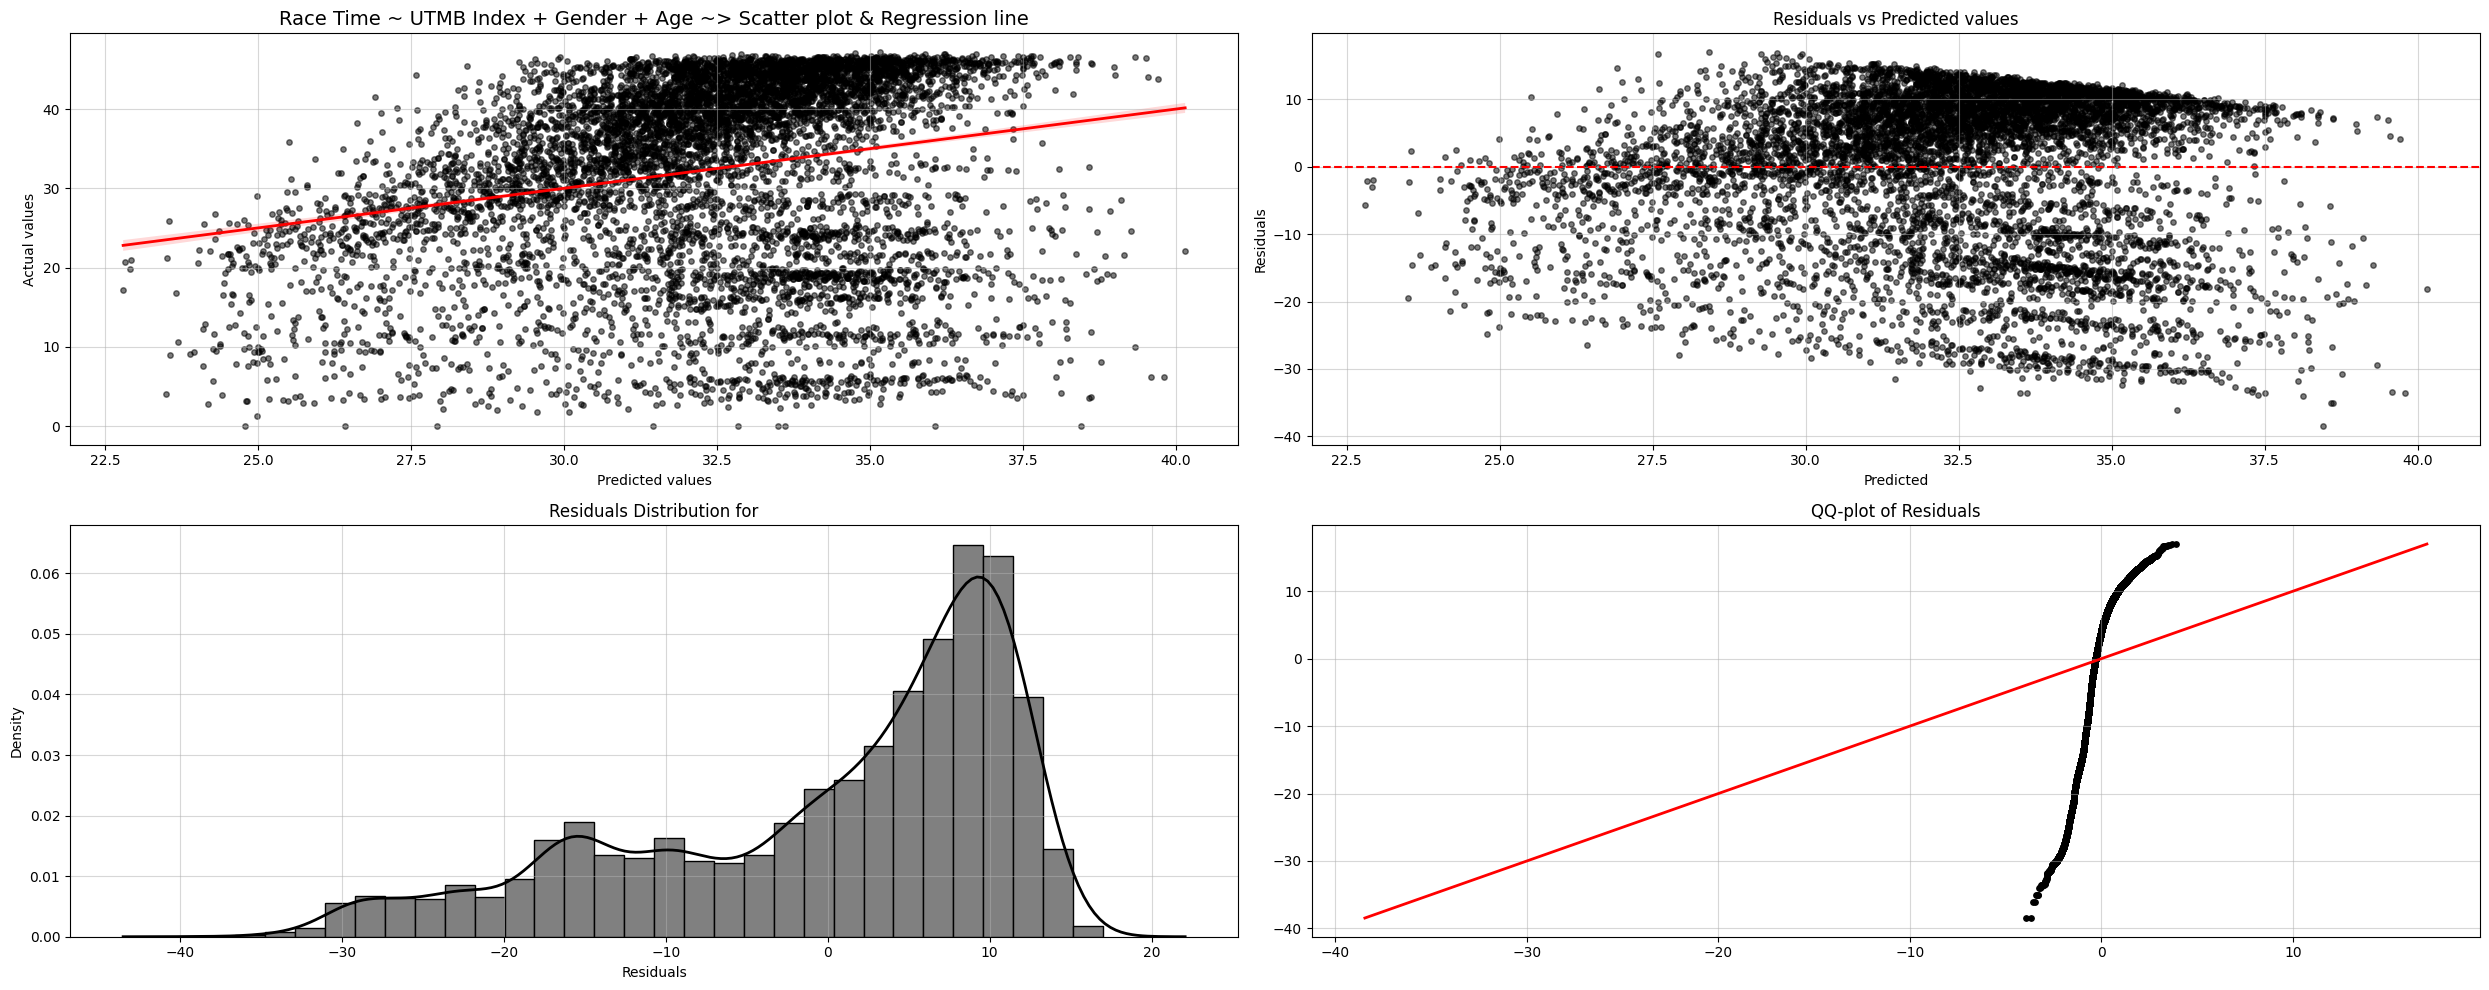

,feature,coef,scaled_coef,p_value,std_err,scaled_std_err,conf_int,scaled_conf_int
0,const,51.284362,inf,0.000000e+00,0.900047,inf,"[49.5202, 53.0486]","[nan, nan]"
1,runner_overall_index,-0.027210,-0.000254,6.672282e-174,0.000955,0.000009,"[-0.0291, -0.0253]","[nan, nan]"
2,gender_Male,1.916373,5.846755,2.745651e-11,0.287549,0.877296,"[1.3527, 2.48]","[nan, nan]"
3,runner_age,-0.120463,-0.013654,2.873784e-25,0.011578,0.001312,"[-0.1432, -0.0978]","[nan, nan]"


R2 = 0.05126070902696922
R2 adjusted = 0.051075721514105554
MAE = 9.67041546547699
RMSE = 11.644722725304112
Pearson correlation coefficient = 0.22640827950180836


In [34]:
# Simple linear model ~ Finishing time

target = "runner_race_time_hours"
target_name = "Race Time"
features = ["runner_overall_index", "runner_gender", "runner_age"]
feature_names = ["UTMB Index", "Gender", "Age"]
data = utmb_split_results_full.copy()
alpha = .3

# Dummies for Gender
data["gender_Male"] = data["runner_gender"].map({"H": 1, "F": 0})

# Prepare
data_model = data[[target] + ["gender_Male" if x=="runner_gender" else x for x in features]].dropna() 
X = sm.add_constant(data_model.drop(columns=target))
y = data_model[target]

linear_model = sm.OLS(y, X)
linear_fit = linear_model.fit()
y_pred = linear_fit.predict(X)
y_pred_summary = linear_fit.get_prediction(X)

# Metrics 
metrics = {
    "coefs": linear_fit.params.reset_index().rename(columns={"index": "feature", 0: "coef"}),
    "scaled coefs": (linear_fit.params / np.std(X, axis=0)).reset_index().rename(columns={"index": "feature", 0: "scaled_coef"}),
    "p-values": linear_fit.pvalues.reset_index().rename(columns={"index": "feature", 0: "p_value"}),
    "standard errors": linear_fit.bse.reset_index().rename(columns={"index": "feature", 0: "std_err"}),
    "scaled standard errors": (linear_fit.bse / np.std(X, axis=0)).reset_index().rename(columns={"index": "feature", 0: "scaled_std_err"}),
    "confidence intervals": round(linear_fit.conf_int(), 4).apply(lambda x: "[" + str(x[0]) + ", " + str(x[1]) + "]", axis=1).reset_index().rename(columns={"index": "feature", 0: "conf_int"}),
    "scaled confidence intervals": round(linear_fit.conf_int() / np.std(X, axis=0), 4).apply(lambda x: "[" + str(x[0]) + ", " + str(x[1]) + "]", axis=1).reset_index().rename(columns={"index": "feature", 0: "scaled_conf_int"}),
    "R2": linear_fit.rsquared,
    "R2 adjusted": linear_fit.rsquared_adj,
    "MAE": mean_absolute_error(y, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
    "Pearson correlation coefficient": pearsonr(y, y_pred)[0],
}

# Plot
fig, ax = plt.subplots(2, 2, figsize=(25, 10))

# Scatter plot with regression line
ax[0,0].set_title(f"{target_name} ~ {" + ".join(feature_names)} ~> Scatter plot & Regression line", fontsize=14)
ax[0,0].scatter(y_pred, y, color="black", s=15, alpha=alpha)
sns.regplot(x=y_pred, y=y, ax=ax[0,0], scatter=False, line_kws={"color":"red", "linewidth":2})
ax[0,0].set_xlabel("Predicted values")
ax[0,0].set_ylabel("Actual values")

# Residuals scatter ~ Linearity assumption, Homoscedasticity, Outliers, Centering around zero
ax[0,1].set_title("Predicted values vs. Residuals", fontsize=14)
residuals = y - y_pred
ax[0,1].scatter(y_pred, residuals, color="black", s=15, alpha=alpha)
ax[0,1].axhline(0, color="red", linestyle="--")
ax[0,1].set_xlabel(f"Predicted")
ax[0,1].set_ylabel("Residuals")
ax[0,1].set_title(f"Residuals vs Predicted values")

# Residuals KDE ~ Normality assumption
ax[1,0].set_title("Residuals distribution", fontsize=14)
ax[1,0].hist(residuals, bins=30, density=True, color="grey", edgecolor="black", alpha=1.0)
sns.kdeplot(residuals, ax=ax[1,0], color="black", linewidth=2)
ax[1,0].set_title(f"Residuals Distribution for")
ax[1,0].set_xlabel("Residuals")
ax[1,0].set_ylabel("Density")

# QQ plot ~ Normal distribution of residuals
ax[1,1].set_title("QQ-plot of Residuals")
osm, osr = stats.probplot(residuals, dist="norm", fit=False)
ax[1,1].scatter(osm, osr, color="black", s=15, alpha=1.0)
min_val = min(osm.min(), osr.min())
max_val = max(osm.max(), osr.max())
ax[1,1].plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2)

for i in [0,1]:
    for j in [0,1]:
        ax[i,j].grid(alpha=.5)

plt.tight_layout()
plt.show()

# Feature metrics
display(
    metrics["coefs"]
    .merge(metrics["scaled coefs"], on="feature")
    .merge(metrics["p-values"], on="feature")
    .merge(metrics["standard errors"], on="feature")
    .merge(metrics["scaled standard errors"], on="feature")
    .merge(metrics["confidence intervals"], on="feature")
    .merge(metrics["scaled confidence intervals"], on="feature")
)

# Model metrics
print(f"R2 = {metrics['R2']}")
print(f"R2 adjusted = {metrics['R2 adjusted']}")
print(f"MAE = {metrics['MAE']}")
print(f"RMSE = {metrics['RMSE']}")
print(f"Pearson correlation coefficient = {metrics['Pearson correlation coefficient']}")

In [35]:
# Predict Finish probability & Finish time
X_predict = pd.DataFrame({
    "const": [1],
    "runner_overall_index": [656],
    "gender_Male": [1],
    "runner_age": [28]
})

y_pred_finish_prob_summary = logit_fit.get_prediction(X_predict)
y_pred_finish_prob = logit_fit.predict(X_predict)
y_pred_finish_prob_ci = list(y_pred_finish_prob_summary.summary_frame(alpha=0.05)[["ci_lower", "ci_upper"]].iloc[0])

print("Predicted finish probability = {:.2f}%".format(y_pred_finish_prob[0] * 100))
print("Confidence interval ~> Average prediction finish probability 95% CI = [{:.2f}, {:.2f}]%".format(y_pred_finish_prob_ci[0] * 100, y_pred_finish_prob_ci[1] * 100))

y_pred_finish_time_summary = linear_fit.get_prediction(X_predict)
y_pred_finish_time = linear_fit.predict(X_predict)
y_pred_finish_time_ci = list(y_pred_finish_time_summary.summary_frame(alpha=0.05)[["mean_ci_lower", "mean_ci_upper"]].iloc[0])
y_pred_finish_time_pi = list(y_pred_finish_time_summary.summary_frame(alpha=0.05)[["obs_ci_lower", "obs_ci_upper"]].iloc[0])

print("\nPredicted finish time | Finish = {:.2f}h".format(y_pred_finish_time[0]))
print("Confidence interval ~> Average prediction finish time 95% CI = [{:.2f}, {:.2f}]".format(y_pred_finish_time_ci[0], y_pred_finish_time_ci[1]))
print("Prediction interval ~> Actual prediction finish time 95% PI = [{:.2f}, {:.2f}]".format(y_pred_finish_time_pi[0], y_pred_finish_time_pi[1]))

Predicted finish probability = 80.17%
Confidence interval ~> Average prediction finish probability 95% CI = [78.88, 81.41]%

Predicted finish time | Finish = 31.98h
Confidence interval ~> Average prediction finish time 95% CI = [31.57, 32.39]
Prediction interval ~> Actual prediction finish time 95% PI = [9.15, 54.81]


About:

What we have: Finish time = f(UTMB index, Gender, Age) + e
- Predicted finish time: 
    - predicted y: y_delta = E[Finishing time | UTMB index, Gender, Age]
    - if we assume e ~ N(0, sigma2) the actual times are normally distributed around the predicted mean.
- It answers the question: If I have UTMB index X, what is the expected finishing time?

What we want: 
- What UTMB index would I need to target to finish in [26, 27]h?
- Given UTMB index, what's the probability of finishing around in [26, 27]h?

Ok:
    - If predicted time for UTMB index = y_delta and e ~ N(0, sigma2)
    - Then: P(26h < finish time < 27h) = Phi[(27 - y_delta) / sigma2] - Phi[(26-y_delta) / sigma2], where Phi is the normal CDF.

Practical use cases:
- If model says UTMB index = 550 -> 29h & UTMB index = 600 -> 27h. Then we know what UTMB index we need to hit the target.
- For certain UTMB index, Age, Gender we get expected finishin time = 28h and 95% CI = [26.5, 29.5], then we can say, we have ~40% chance of breaking 27h.

Two directions you can take
- Analytical: directly manipulate regression equations (easy if linear).
- Simulation-based: simulate many possible race outcomes from your model distribution → count proportion below/within a target.

1. Deterministic / Analytical version: What UTMB index gives a predicted mean time inside [26, 27]h?
---

We have: 
- predicted T = B0 + B1 * UTMB Index + B2 * Age + B3 * Gender
- Then, UTMB index = [T - (B0 + B2 * Age + B3 * Gender)] / B1
    - UTMB index for 26h = [26 - (B0 + B2 * Age + B3 * Gender)] / B1
    - UTMB index for 27h = [27 - (B0 + B2 * Age + B3 * Gender)] / B1
- This gives predicted average time, it ignores uncertainty (residual variation)
- It answers: Wwhat mean UTMB gives average finishing time in [26, 27]h.
- It does not answer: What UTMB index gives a good change of actually finishing in [26,27]h.

2. Probabilistic approach: For a given UTMB index, what is the probability that my actual finish time will land in [26, 27]h?
---

What we are really asking: Given my age & gender and a candidate UTMB index, what is the probability that my actual finish time will be in [26, 27]h?
- If we assume that residuals are approximately Normal with standard deviation sigma, we then compute:
- Predicted average time = T(Age, Gender, UTMB index)
- Then: P(26 < T < 27) = PHI(27-mu / sigma) - PHI(26-mu / sigma), where PHI is the standard normal CDF.

We can scan a grid of UTMB index values, compute predicted average time for each and then compute this probability. We get a curve of probability vs. UTMB index.
- Read UTMB index that maximizes probability of finishing in [26, 27]h.
- Find the smallest UTMB index achieving at least e.g. 70% chance.
- etc.

3. Brute force 
---
- Choose a gird of UTMB indices
- Compute predicted average time & probability of finishing in [26, 27]h by the normal CDF formula
- Inspect the probability for UTMB indices we care about.

4. Additional 
---
The formulas above assume sigma captures most uncertainty. If you want to fold in uncertainty of the regression coefficients (so your probability accounts for both residual scatter and coefficient uncertainty), you can:

- Compute the full predictive distribution for an individual: approximate variance = sigma2 + Var(mu_hat), where Var(mu_hat) = .... covariance of coefficients and use that combined sd for the normal CDF. 
- Or, simulate coefficients from a multivariate normal N(beta_hat, cov_beta) and residualls and then simulate outcome (Monte Carlo).

But for most practical cases with reasonable data size, using sigma alone (prediction interval) is fine.

In [ ]:
# GOGO! :)

target_lower = 26
target_upper = 27

utmb_indices = np.arange(400, 951, 1)
X_predict = pd.DataFrame({
    "const": 1, 
    "runner_overall_index": utmb_indices,
    "gender_Male": 1, 
    "runner_age": 28 
})

y_pred = linear_fit.predict(X_predict)
y_pred_summary = linear_fit.get_prediction(X_predict).summary_frame(alpha=0.05)
resid_std = linear_fit.resid.std()

from scipy.stats import norm
probs_between_26_27 = norm.cdf(x=27, loc=y_pred, scale=resid_std) - norm.cdf(x=26, loc=y_pred, scale=resid_std)
probs_under_27 = norm.cdf(27, loc=y_pred, scale=resid_std)

df = pd.DataFrame({
    "runner_overall_index": utmb_indices,
    "y_pred": y_pred,

    "y_pred_ci_95_lower": y_pred_summary["mean_ci_lower"],
    "y_pred_ci_95_upper": y_pred_summary["mean_ci_upper"],

    "y_pred_pi_95_lower": y_pred_summary["obs_ci_lower"],
    "y_pred_pi_95_upper": y_pred_summary["obs_ci_upper"],

    "prob_between_26_27": probs_between_26_27,
    "prob_under_27": probs_under_27
})

# UTMB index to finish under 27h
target_time = 27
target_prob = 0.95
# Just invert what we have now for Probability for under 27h = 0.95 ...

beta_const = linear_fit.params["const"]
beta_index = linear_fit.params["runner_overall_index"]
beta_age = linear_fit.params["runner_age"]
beta_gender = linear_fit.params["gender_Male"] 

z = norm.ppf(target_prob)   
utmb_index_required = (target_time - (beta_const + beta_age*28 + beta_gender*1) - resid_std*z) / beta_index

df
utmb_index_required

np.float64(1542.8969909318469)

Notes: 
- Long left-skewed distribution of finish times breaks one of the main assumptions of linear regression: normally distributed residuals -->  Predictions are biased: The model will “overpredict” for fast finishers and “underpredict” for slow finishers.

Quantile regression
---

C:\Users\Urh\AppData\Local\Temp\ipykernel_23288\2615779859.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = plot_df.groupby("bin")["y_pred"].mean()
C:\Users\Urh\AppData\Local\Temp\ipykernel_23288\2615779859.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  calibration = plot_df.groupby("bin", observed=False).apply(lambda x: np.mean(x["y_actual"] <= x["y_pred"])).reset_index().rename(columns={0: "proportion_below"})
C:\Users\Urh\AppData\Local\Temp\ipykernel_23288\2615779859.py:67: FutureWar

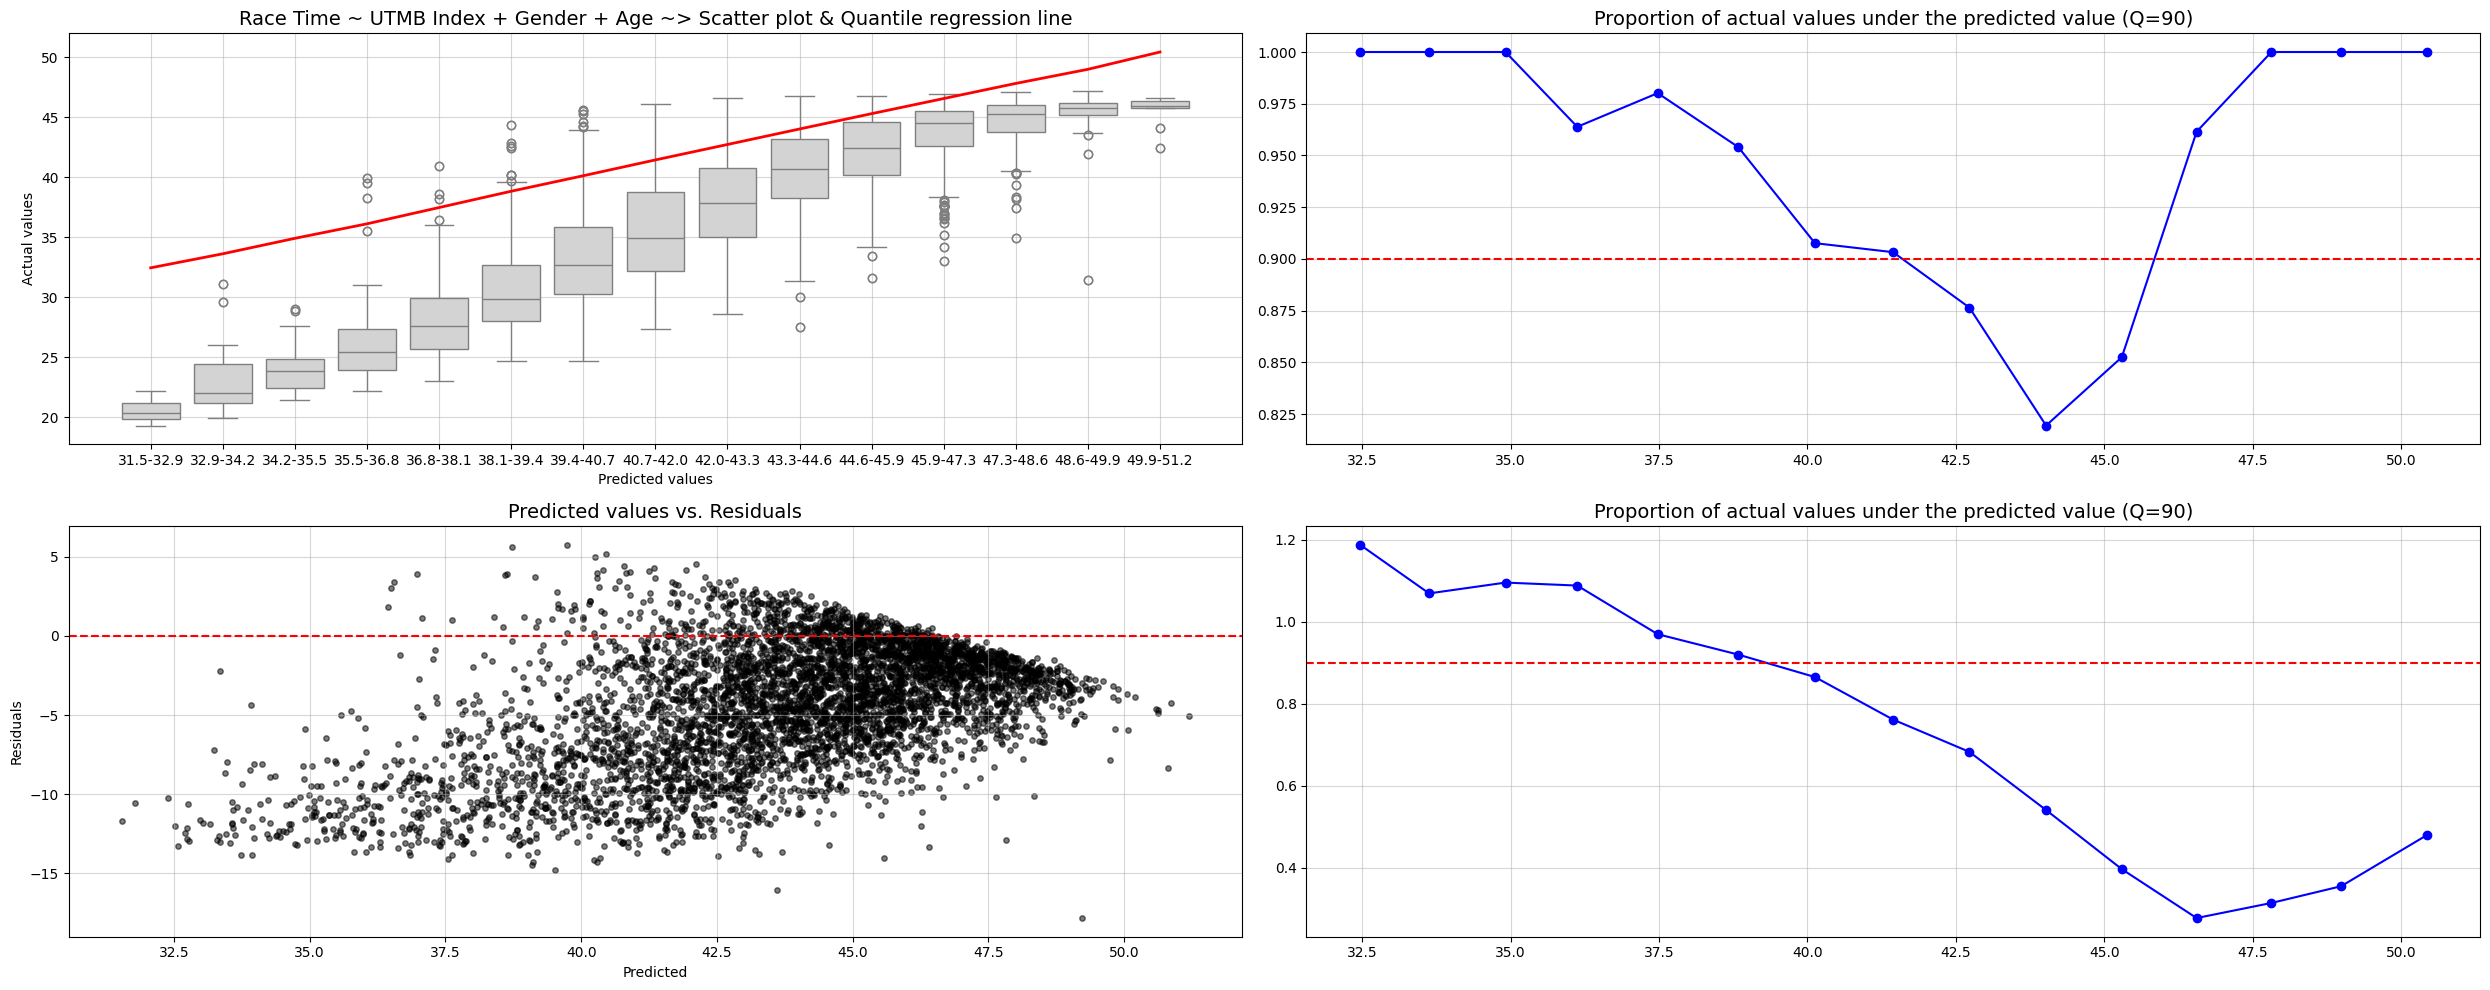

,feature,coef,p_value,std_err,conf_int
0,const,61.051311,0.000000,0.369012,"[60.328, 61.7746]"
1,runner_overall_index,-0.031831,0.000000,0.000318,"[-0.0325, -0.0312]"
2,gender_Male,-0.043403,0.745422,0.133675,"[-0.3054, 0.2186]"
3,runner_age,0.016229,0.003006,0.005468,"[0.0055, 0.0269]"


Pseudo R2 = 0.1916
MAE = 4.7249
RMSE = 5.8822
Pinball-loss = 2.3624
Coverage probability = 0.8998 (Selected quantile = 0.9)


In [121]:
# Simple Quantile model ~ Finishing time
from sklearn.metrics import mean_pinball_loss

target = "runner_race_time_hours"
target_name = "Race Time"
features = ["runner_overall_index", "runner_gender", "runner_age"]
feature_names = ["UTMB Index", "Gender", "Age"]
data = utmb_split_results_full.query("runner_is_finisher").copy()
selected_quantile = 0.9
alpha = .3

# Dummies for Gender
data["gender_Male"] = data["runner_gender"].map({"H": 1, "F": 0})

# Prepare
data_model = data[[target] + ["gender_Male" if x=="runner_gender" else x for x in features]].dropna() 
X = sm.add_constant(data_model.drop(columns=target))
y = data_model[target]

quantile_model = sm.QuantReg(y, X)
quantile_fit = quantile_model.fit(q=selected_quantile)
y_pred = quantile_fit.predict(X)
y_pred_summary = quantile_fit.get_prediction(X)

# Metrics 
metrics = {
    "coefs": quantile_fit.params.reset_index().rename(columns={"index": "feature", 0: "coef"}),
    "p-values": quantile_fit.pvalues.reset_index().rename(columns={"index": "feature", 0: "p_value"}),
    "standard errors": quantile_fit.bse.reset_index().rename(columns={"index": "feature", 0: "std_err"}),
    "confidence intervals": round(quantile_fit.conf_int(), 4).apply(lambda x: "[" + str(x[0]) + ", " + str(x[1]) + "]", axis=1).reset_index().rename(columns={"index": "feature", 0: "conf_int"}),
    "Pseudo R2": quantile_fit.prsquared,
    "MAE": mean_absolute_error(y, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y, y_pred)),
    "Pinball-loss": mean_pinball_loss(y, y_pred),
    "Coverage probability": np.mean(y <= y_pred),
}

# Plot
fig, ax = plt.subplots(2, 2, figsize=(25, 10))

# Binned proportions of actual values above/below predicted quantile values with quantile regression line
# y_pred_bin = pd.qcut(y_pred, q=20, labels=False)
nr_bins = 15
pred_bins = np.linspace(y_pred.min(), y_pred.max(), nr_bins + 1)
bin_labels = [f"{round(pred_bins[i],1)}-{round(pred_bins[i+1],1)}" for i in range(len(pred_bins)-1)]
y_pred_bin = pd.cut(y_pred, bins=pred_bins, labels=bin_labels, include_lowest=True)

plot_df = pd.DataFrame({
    "y_pred": y_pred, 
    "y_actual": y, 
    "bin": y_pred_bin
    })

bin_means = plot_df.groupby("bin")["y_pred"].mean()

ax[0,0].set_title(f"{target_name} ~ {" + ".join(feature_names)} ~> Scatter plot & Quantile regression line", fontsize=14)
sns.boxplot(x="bin", y="y_actual", data=plot_df, ax=ax[0,0], color="lightgrey")
ax[0,0].plot(range(nr_bins), bin_means, color="red", linewidth=2, label="Predicted 90th percentile")
# qr_fit = sm.QuantReg(y, X).fit(q=selected_quantile)
# ax[0,0].plot(y_pred, qr_fit.predict(X), color="red", linewidth=2, label=f"Quantile {selected_quantile}")
ax[0,0].set_xlabel("Predicted values")
ax[0,0].set_ylabel("Actual values")

# Proportion of actual values above/below predicted quantile values per bins
ax[0,1].set_title("Proportion of actual values under the predicted value (Q=90)", fontsize=14)
calibration = plot_df.groupby("bin", observed=False).apply(lambda x: np.mean(x["y_actual"] <= x["y_pred"])).reset_index().rename(columns={0: "proportion_below"})
calibration["y_pred_mean"] = plot_df.groupby("bin")["y_pred"].mean().values
ax[0,1].plot(calibration["y_pred_mean"], calibration["proportion_below"], marker="o", linestyle="-", color="blue")
ax[0,1].axhline(0.9, color="red", linestyle="--", label="Target quantile = 0.9")

# Residuals scatter ~ Linearity assumption, Homoscedasticity, Outliers, Centering around zero
ax[1,0].set_title("Predicted values vs. Residuals", fontsize=14)
residuals = y - y_pred
ax[1,0].scatter(y_pred, residuals, color="black", s=15, alpha=alpha)
ax[1,0].axhline(0, color="red", linestyle="--")
ax[1,0].set_xlabel(f"Predicted")
ax[1,0].set_ylabel("Residuals")

# Pinball-Loss per bins
ax[1,1].set_title("Proportion of actual values under the predicted value (Q=90)", fontsize=14)
pinball = plot_df.groupby("bin", observed=False).apply(lambda x: mean_pinball_loss(x["y_actual"], x["y_pred"], alpha=selected_quantile)).reset_index().rename(columns={0: "pinball_loss"})
pinball["y_pred_mean"] = plot_df.groupby("bin")["y_pred"].mean().values
ax[1,1].plot(pinball["y_pred_mean"], pinball["pinball_loss"], marker="o", linestyle="-", color="blue")
ax[1,1].axhline(0.9, color="red", linestyle="--", label="Target quantile = 0.9")

for i in [0,1]:
    for j in [0,1]:
        ax[i,j].grid(alpha=.5)

plt.tight_layout()
plt.show()

# Feature metrics
display(
    metrics["coefs"]
    .merge(metrics["p-values"], on="feature")
    .merge(metrics["standard errors"], on="feature")
    .merge(metrics["confidence intervals"], on="feature")
)

# Model metrics
print(f"Pseudo R2 = {metrics['Pseudo R2']:.4f}")
print(f"MAE = {metrics['MAE']:.4f}")
print(f"RMSE = {metrics['RMSE']:.4f}")
print(f"Pinball-loss = {metrics['Pinball-loss']:.4f}")
print(f"Coverage probability = {metrics['Coverage probability']:.4f} (Selected quantile = {selected_quantile})")

Survival analysis - Acceleraited Failure Time [AFT] model
---

Survival analysis vs. Survival analysis:
- Linear regression is simple and very flexible for scenario analysis (e.g., "what UTMB index do I need to have a 95% chance under 27h").
- Survival models are statistically "more correct" if you want to handle DNFs and skewness properly.
- But if you accept ignoring DNFs or fixing them at max time, linear regression can give very similar insights in practice.
- An AFT model is essentially linear regression on a transformed target, usually log(T) (or another suitable distribution like Weibull).
- DNFs are censored observations: you only know that the runner didn’t finish before the cutoff.
- Linear regression on finishing times is great for scenario analysis if you assume the runner finishes.
- AFT / survival is more statistically sound if you want to include DNFs naturally.


Treat finishing time as a "time-to-event" variable- DNFs are censored at the race cutoff.
- AFT model with log-normal distribution: log(T) = B0 + B1 * UTMB index + B2 * Age + B3 * Gender + E
- E is assumed to follow a known distribution (log-normal, Weibull, etc.).

Pros: 
- With this we handle DNFs naturally as censored data.
- Can handle skewed distributions (log-normal, Weibull) without transformation hacks.
- You can calculate survival probabilities: probability of finishing under a certain time.
- AFT models do not require perfect normality.
    - It assumues a parametric distribution (e.g., log-normal, Weibull, exponential) for residuals.
    - You can fit a Weibull AFT even if log(T) is not exactly normal; the model handles skew inherently.

Cons: 
- Coefficients are interpreted as multiplicative effects on time.
- Prediction intervals are a bit more complex to compute.
- Linear "predictor + residual" framework for simulations or simple plotting is less direct.

Problem for censored data here:
- A DNF is not just an unknown finish time, it’s a hard “failure” event.
- The exact time at which the runner quit isn’t really informative for predicting their successful finish time.
- So in your case, treating DNFs as “event = 0” and not using their duration as informative is correct.
- We should not give credit to DNFs with long durations.

C-index = 0.8030340956128712
AIC = 56812.22860781036
LL = -28401.11430390518


coef  exp(coef)  se(coef)  coef lower 95%  \
param   covariate                                                             
lambda_ Intercept             4.311288  74.536427  0.009573        4.292526   
        runner_overall_index -0.001125   0.998875  0.000012       -0.001149   
        runner_age            0.000567   1.000567  0.000111        0.000350   
        gender_Male           0.006598   1.006619  0.002829        0.001053   
rho_    Intercept             2.426674  11.321162  0.007358        2.412252   

                              coef upper 95%  exp(coef) lower 95%  \
param   covariate                                                   
lambda_ Intercept                   4.330050            73.151008   
        runner_overall_index       -0.001102             0.998852   
        runner_age                  0.000784             1.000350   
        gender_Male                 0.012142             1.001053   
rho_    Intercept                   2.441095            11.159068   

                              exp(coef) upper 95%  cmp to           z  \
param   covariate                                                       
lambda_ Intercept                       75.948084     0.0  450.375751   
        runner_overall_index             0.998899     0.0  -93.346955   
        runner_age                       1.000785     0.0    5.121513   
        gender_Male                      1.012216     0.0    2.332163   
rho_    Intercept                       11.485611     0.0  329.803260   

                                         p   -log2(p)  
param   covariate                                      
lambda_ Intercept             0.000000e+00        inf  
        runner_overall_index  0.000000e+00        inf  
        runner_age            3.030932e-07  21.653735  
        gender_Male           1.969213e-02   5.666237  
rho_    Intercept             0.000000e+00        inf

Predicted median finish time [h]: 35.2772502749792
Prediction inteval [h]: [ 40.14617936132994 ] ,[ 28.029418759723544 ]
Probability of finishing under 27h: 3.30%


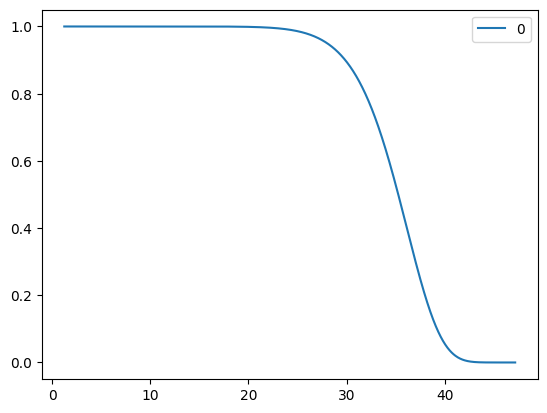

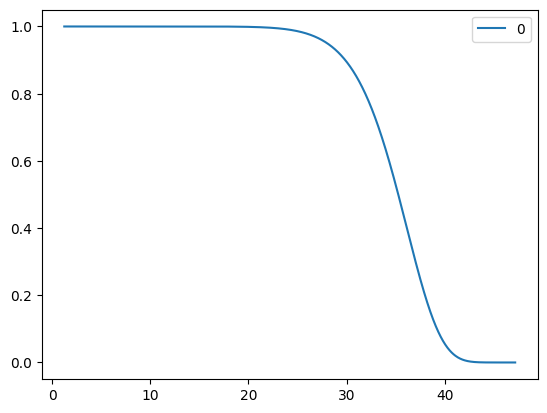

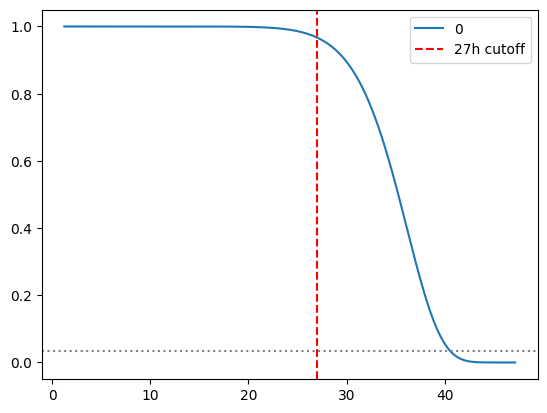

<Axes: title={'center': 'Probability of finishing by time t'}>

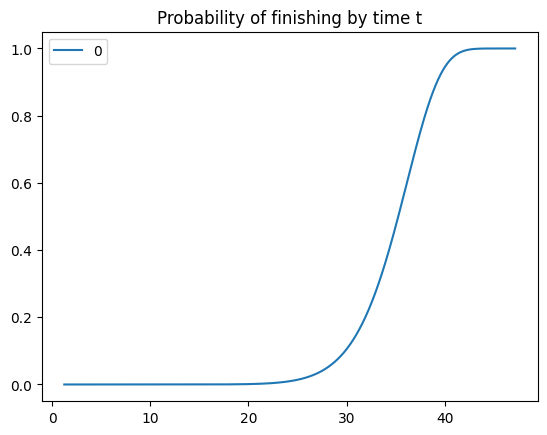

In [ ]:
from lifelines import WeibullAFTFitter, LogNormalAFTFitter, LogLogisticAFTFitter
# Distribution choice = important mainly for extrapolation / tail behaviour, compare with AIC.

target = "runner_race_time_hours"
target_name = "Race Time"
features = ["runner_overall_index", "runner_gender", "runner_age", "runner_is_finisher"]
feature_names = ["UTMB Index", "Gender", "Age", "Finisher"]
data = utmb_split_results_full.copy()
alpha = .3

# Prepare data
aft_data = data[[target] + features].copy()
aft_data["event"] = aft_data["runner_is_finisher"].astype(int)
aft_data["duration"] = aft_data["runner_race_time_hours"]
aft_data["gender_Male"] = np.where(aft_data["runner_gender"] == "H", 1, 0)
aft_data = aft_data.loc[aft_data[["runner_overall_index", "runner_gender", "runner_age", "runner_is_finisher"]].notnull().mean(axis=1) == 1, :].reset_index(drop=True)
aft_data = aft_data.loc[aft_data["duration"] > 0, :].reset_index(drop=True)

# Fit
aft = WeibullAFTFitter()
aft.fit(aft_data, duration_col="duration", event_col="event",
        formula="runner_overall_index + runner_age + gender_Male")

# How good the model is? 
# Concordance index ~ something like AUC
c_index = aft.score(aft_data, scoring_method="concordance_index")
aic = aft.AIC_
ll = aft.log_likelihood_
print("C-index = {}".format(c_index))
print("AIC = {}".format(aic))
print("LL = {}".format(ll))

# Summary
display(aft.summary)

# Predict
X_predict = pd.DataFrame({
    "runner_overall_index": [656],
    "gender_Male": [1], 
    "runner_age": [28] 
})

median_pred = aft.predict_median(X_predict)
print("Predicted median finish time [h]:", median_pred.values[0])
print("Prediction inteval [h]: [", aft.predict_percentile(X_predict, p=0.05)[0], "] ,[", aft.predict_percentile(X_predict, p=0.95)[0], "]") 

# Probability of finishing before some time:
aft.predict_survival_function(X_predict).plot() 

# Probability of finishing under 27h
sf = aft.predict_survival_function(X_predict)
prob_after_27h = np.interp(27, sf.index, sf.values[:, 0])
prob_under_27h = 1 - prob_after_27h
print(f"Probability of finishing under 27h: {prob_under_27h:.2%}")

# Visual sanity check
sf = aft.predict_survival_function(X_predict)
sf.plot(label="Survival function")
plt.axvline(27, color="red", linestyle="--", label="27h cutoff")
plt.axhline(prob_under_27h, color="grey", linestyle=":")
plt.legend()
plt.show()


# Better intepretation
sf = aft.predict_survival_function(X_predict)
cdf = 1 - sf
cdf.plot(title="Probability of finishing by time t")

---
Additional calculations

In [ ]:
# Average pace needed to run [26-27h]
utmb_length_km = 171
utmb_elevelation_m = 10_040
goal_time_low_min = 26 * 60
goal_time_high_min = 27 * 60

print("Length = {}km".format(utmb_length_km))
print("Elevation gain = {:,}m".format(utmb_elevelation_m))


elevation_per_kilometer = utmb_elevelation_m / utmb_length_km
print("\nElevation per kilometer = {:.2f}m".format(elevation_per_kilometer))
print("Elevation for kilometer uphill (loop course) = {:.2f}m".format(elevation_per_kilometer * 2))

avg_pace_min_km_low = goal_time_low_min / utmb_length_km
avg_pace_min_km_high = goal_time_high_min / utmb_length_km
print("\nAverage pace [min/km] for [26h, 27h] = {:.2f} - {:.2f}".format(avg_pace_min_km_low, avg_pace_min_km_high))

Length = 171km
Elevation gain = 10,040m

Elevation per kilometer = 58.71m
Elevation for kilometer uphill (loop course) = 117.43m

Average pace [min/km] for [26h, 27h] = 9.12 - 9.47


In [ ]:
# GPX to Tabular data
import gpxpy
with open("UTMB_2025_course.gpx", "r") as f:
    utmb_gpx = gpxpy.parse(f)

# Slope categories
slope_categories = {
    "Flat": (0,1),
    "Very easy": (1,3),
    "Easy": (3,7),
    "Moderate": (7, 12),
    "Steep": (12, 20),
    "Very steep": (20, 30),
    "Extreme": (30, np.inf) 
}

def classify_slope(slope_percent, slope_categories):
    if slope_percent > list(slope_categories.values())[0][1]:
        direction = "Uphill"
    elif abs(slope_percent) > list(slope_categories.values())[0][1]:
        direction = "Downhill"
    else:
        direction = "Flat"

    for cat_name, (min_val, max_val) in slope_categories.items():
        if min_val <= abs(slope_percent) < max_val:
            if direction == "Flat":
                return cat_name
            else:
                return direction + " | " + cat_name

# -------------------------------
# Create a tabular data
# -------------------------------

# GPX file is a container that can hold multiple tracks, routes, ...
# A track represents a complete path / activity
track = utmb_gpx.tracks[0]
points = []
i = 0

# Inside track there are track segments - a continuous portion of a track
# Used for when there are gaps in GPS record or for logical separations

total_distance_2d = 0
total_distance_3d = 0
total_elevation_gain = 0
total_elevation_loss = 0

for segment in track.segments:

    point_distance_2d = 0
    point_distance_3d = 0
    point_elevation_gain = 0
    point_elevation_loss = 0
    slope_percent = 0
    slope_class = list(slope_categories.keys())[0]

    prev_point = None
    prev_elevation = None
    
    # Each segment contains track points
    # Each point stores a specific location along the track
    # Points are ordered in the sequence they were recorded
    for point in segment.points:
        if prev_point is not None:

            # 2D distance - horizontal distance along the map plane
            point_distance_2d = point.distance_2d(prev_point)
            total_distance_2d += point_distance_2d

            # 3D distance - account for the vertical change (3D >= 2D)
            point_distance_3d = point.distance_3d(prev_point)
            total_distance_3d += point_distance_3d

            point_elevation = point.elevation - prev_elevation
            if point_elevation >= 0:
                point_elevation_loss = 0
                point_elevation_gain = point_elevation
                total_elevation_gain += point_elevation
            else:
                point_elevation_gain = 0
                point_elevation_loss = abs(point_elevation)
                total_elevation_loss += abs(point_elevation)

            if point_distance_2d != 0:
                slope_percent = (point.elevation - prev_elevation) / point_distance_2d * 100
            else: 
                slope_percent = 0
        
        points.append({
            "point_index": i,
            "latitude": point.latitude,
            "longitude": point.longitude,
            "elevation_m": point.elevation,

            "point_distance_2d_m": point_distance_2d,
            "point_distance_3d_m": point_distance_3d,
            "point_elevation_gain_m": point_elevation_gain,
            "point_elevation_loss_m": point_elevation_loss,
            "slope_perc": slope_percent,
            "slope_class": classify_slope(slope_percent, slope_categories),

            "total_distance_2d_m": total_distance_2d,
            "total_distance_3d_m": total_distance_3d,
            "total_elevation_gain_m": total_elevation_gain,
            "total_elevation_loss_m": total_elevation_loss,

        })

        prev_point = point
        prev_elevation = point.elevation
        i += 1


utmb_tabular = pd.DataFrame(points)

In [ ]:
# About

print("About UTMB Course ~ 2025 GPX")
print("----------------------------------------")

print("\nTotal:")
print("Distance = {:,.2f} [km]".format(utmb_tabular["point_distance_2d_m"].sum()))
print("Elevation gain = {:,.2f} [m]".format(utmb_tabular["point_elevation_gain_m"].sum()))
print("Elevation loss = {:,.2f} [m]".format(utmb_tabular["point_elevation_loss_m"].sum()))

print("\nFlat slopes:")
utmb_tabular_flat = utmb_tabular[utmb_tabular["slope_class"] == "Flat"].reset_index(drop=True)
print("Proportion = {:.2f}%".format(utmb_tabular_flat["point_distance_2d_m"].sum() / utmb_tabular["point_distance_2d_m"].sum() * 100))
print("Avg. slope ~ mean = {:.2f}%".format(utmb_tabular_flat["slope_perc"].mean()))
print("Avg. slope ~ distance = {:.2f}%".format((utmb_tabular_flat["slope_perc"] * utmb_tabular_flat["point_distance_2d_m"]).sum() / utmb_tabular_flat["point_distance_2d_m"].sum()))

print("\nUphill slopes:")
utmb_tabular_uphill = utmb_tabular[utmb_tabular["slope_class"].str.contains("Uphill")].reset_index(drop=True)
print("Proportion = {:.2f}%".format(utmb_tabular_uphill["point_distance_2d_m"].sum() / utmb_tabular["point_distance_2d_m"].sum() * 100))
print("Avg. slope ~ mean = {:.2f}%".format(utmb_tabular_uphill["slope_perc"].mean()))
print("Avg. slope ~ distance = {:.2f}%".format((utmb_tabular_uphill["slope_perc"] * utmb_tabular_uphill["point_distance_2d_m"]).sum() / utmb_tabular_uphill["point_distance_2d_m"].sum()))
print("----------------------------")
for slope_class, proportion in (utmb_tabular_uphill["slope_class"].value_counts(normalize=True) * 100).items():
    print("{} ~> {:.2f}%".format(slope_class.replace("Uphill | ", ""), proportion))

print("\nDownhill slopes:")
utmb_tabular_downhill = utmb_tabular[utmb_tabular["slope_class"].str.contains("Downhill")].reset_index(drop=True)
print("Proportion = {:.2f}%".format(utmb_tabular_downhill["point_distance_2d_m"].sum() / utmb_tabular["point_distance_2d_m"].sum() * 100))
print("Avg. slope ~ mean = {:.2f}%".format(abs(utmb_tabular_downhill["slope_perc"].mean())))
print("Avg. slope ~ distance = {:.2f}%".format((utmb_tabular_downhill["slope_perc"] * utmb_tabular_downhill["point_distance_2d_m"]).sum() / utmb_tabular_downhill["point_distance_2d_m"].sum()))
print("----------------------------")
for slope_class, proportion in (utmb_tabular_downhill["slope_class"].value_counts(normalize=True) * 100).items():
    print("{} ~> {:.2f}%".format(slope_class.replace("Downhill | ", ""), proportion))

About UTMB Course ~ 2025 GPX
----------------------------------------

Total:
Distance = 172,625.21 [km]
Elevation gain = 10,509.55 [m]
Elevation loss = 10,508.60 [m]

Flat slopes:
Proportion = 8.18%
Avg. slope ~ mean = -0.01%
Avg. slope ~ distance = -0.04%

Uphill slopes:
Proportion = 46.71%
Avg. slope ~ mean = 20.50%
Avg. slope ~ distance = 12.99%
----------------------------
Steep ~> 27.90%
Very steep ~> 23.40%
Extreme ~> 16.80%
Moderate ~> 16.74%
Easy ~> 10.61%
Very easy ~> 4.55%

Downhill slopes:
Proportion = 45.10%
Avg. slope ~ mean = 18.72%
Avg. slope ~ distance = -13.46%
----------------------------
Steep ~> 26.31%
Very steep ~> 21.51%
Moderate ~> 16.60%
Extreme ~> 15.11%
Easy ~> 13.75%
Very easy ~> 6.73%


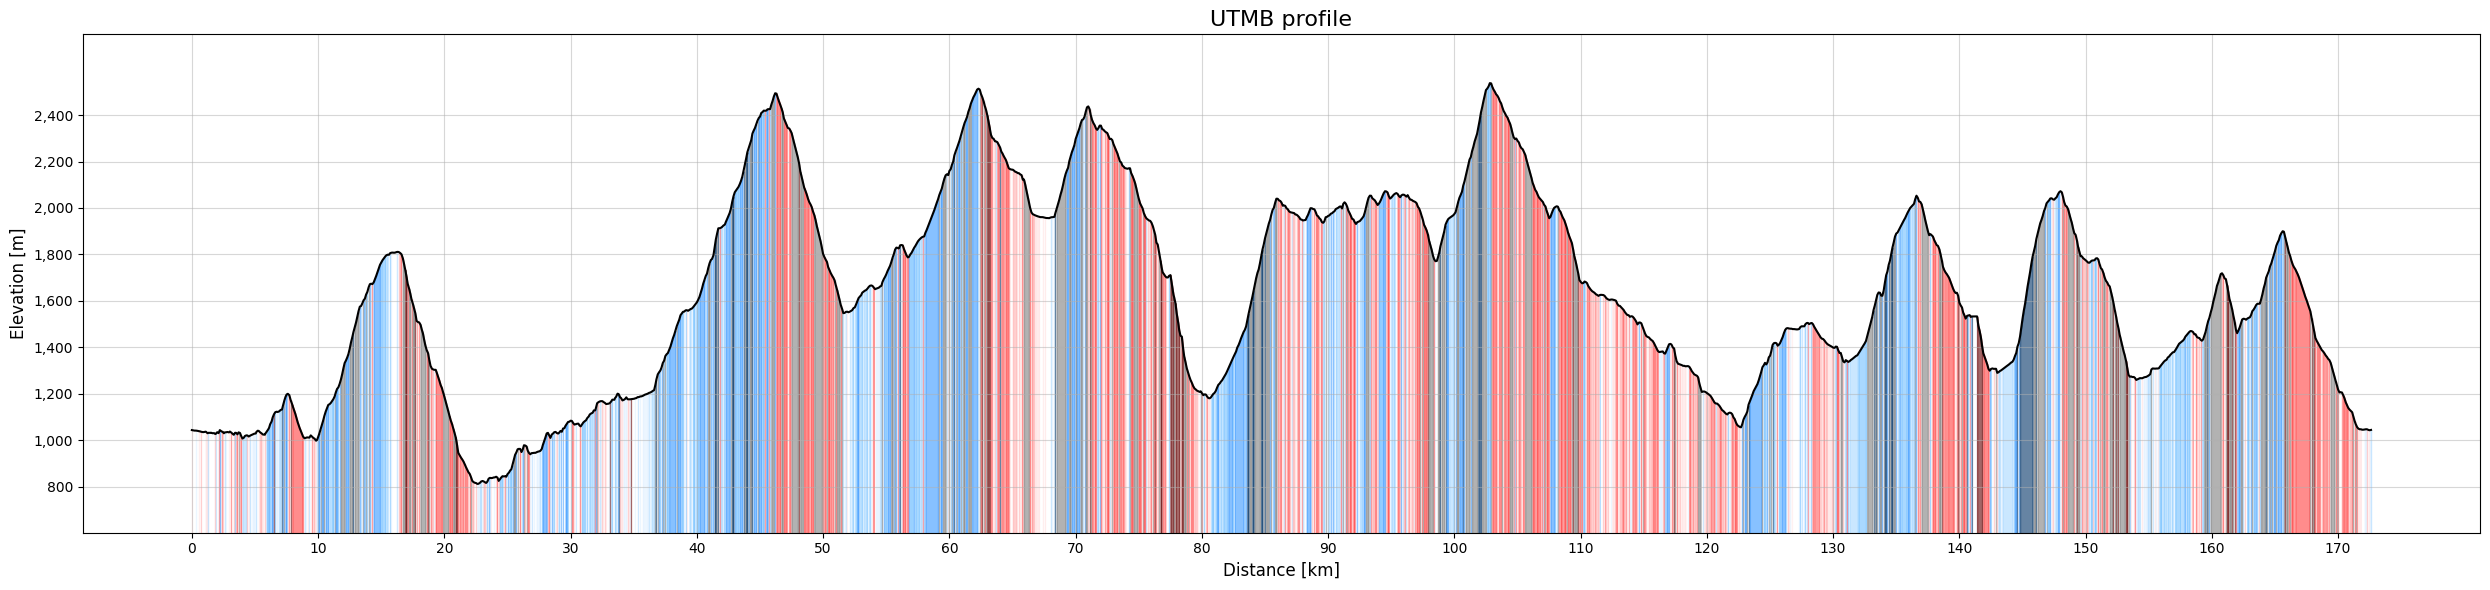

In [ ]:
# Plot

fig, ax = plt.subplots(1,1, figsize = (25, 6))

slope_colors = {
    "Flat": "white",
    "Uphill | Very easy": "#E0F0FF",
    "Uphill | Easy": "#A8D8FF",
    "Uphill | Moderate": "#70BFFF",
    "Uphill | Steep": "#3898FF",
    "Uphill | Very steeo": "#0066CC",
    "Uphill | Extreme": "#003366",
    
    "Downhill | Very easy": "#FFE0E0",
    "Downhill | Easy": "#FFB0B0",
    "Downhill | Moderate": "#FF6060",
    "Downhill | Steep": "#FF4040",
    "Downhill | Very steeo": "#CC0000",
    "Downhill | Extreme": "#660000",
}

plot_data = utmb_tabular.copy()
distance_2d_100m_edges = np.arange(0, utmb_tabular["total_distance_2d_m"].max() + 110, 100)
plot_data["total_distance_2d_m_bin"] = pd.cut(plot_data["total_distance_2d_m"], bins=distance_2d_100m_edges, right=False)
plot_data = plot_data.groupby("total_distance_2d_m_bin", observed=True).aggregate({
    "total_distance_2d_m": "min",
    "elevation_m": "max",
    "slope_perc": "mean"
    })
plot_data["slope_class"] = plot_data["slope_perc"].apply(lambda s: classify_slope(s, slope_categories))

ax.set_title("UTMB profile", fontsize=16)

slope_classes = plot_data["slope_class"].values
change_idx = [0] + (np.where(slope_classes[1:] != slope_classes[:-1])[0] + 1).tolist() + [len(plot_data["total_distance_2d_m"])]
for start, end in zip(change_idx[:-1], change_idx[1:]):
    sc = slope_classes[start]
    color = slope_colors.get(sc, "grey")
    ax.fill_between(plot_data["total_distance_2d_m"][start:end],  plot_data["elevation_m"][start:end], color=color, alpha=0.6)

ax.plot(plot_data["total_distance_2d_m"], plot_data["elevation_m"], color="black")

ax.set_xticks(np.arange(0, plot_data["total_distance_2d_m"].max() + 1, 10_000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1000:,.0f}"))

ax.set_yticks(np.arange(0, plot_data["elevation_m"].max() + 1, 200))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_ylim( plot_data["elevation_m"].min() - 0.5*plot_data["elevation_m"].std(),  plot_data["elevation_m"].max() + 0.5*plot_data["elevation_m"].std())

ax.set_xlabel("Distance [km]", fontsize=12)
ax.set_ylabel("Elevation [m]", fontsize=12)

plt.grid(alpha=.5)
plt.tight_layout()
plt.show()